## LiMPIEZA E INTREGACIÓN DE LOS DATOS EN LA VISTA MINABLE
-  Autor: Germán Homero Morán Figueroa
- Descripción: Este notebook permite realizar la limpieza y depuración de cada una de las fuentes
y Contruir la vista minable que sirve de insumo para los modelo de Machine Learning

In [2]:
# Librerias y dependencias
# =========================================================================
import pandas as pd
import numpy as np
from unidecode import  unidecode
import plotly.express as px
import re
pd.options.display.max_columns = None

In [3]:
# Lectura de lso datsets
# ====================================================
Productions_Events = pd.read_csv("../Data/Bronze/Production_events_3.csv")
fields = pd.read_csv("../Data/Bronze/Fields_3.csv")
Productions_Events.tail(3)

,ID_EVENTO,ID_LOTE,ID_FINCA,ID_PROD,LAT_LOTE,LONG_LOTE,FECHA_SIEMBRA,TIPO_SIEMBRA,NUM_SEMILLAS,SEM_TRATADAS,DIST_SURCOS,DIST_PLANTAS,TIPO_CULTIVO,COLOR_ENDOSPERMO,SEM_POR_SITIO,TIPO_DE_SEMILLA,HABITO_CRECIMIENTO,MATERIAL_GENETICO,OBJ_RDT,CULT_ANT,DRENAJE,FECHA_EMERGENCIA,POBLACION_20DIAS,FECHA_FLORACION,FECHA_COSECHA,METODO_COSECHA,RDT,PROD_COSECHADO,NOMBRE_LOTE,ORIGEN_SEMILLA,INOCULACION_SEMILLAS,NUEVA_INOCULACION_SEMILLAS,PRODUCTO_USADO,TIPO_MATERIAL,NUEVO_MATERIAL_GENETICO,OTRO_CULT_ANT,RESIEMBRA,CANTIDAD_TOTAL,HUMEDAD,ALMACENAMIENTO_FINCA,OBSERVACIONES_COSECHA,DEPARTAMENTO,MUNICIPIO,AREA
995,4673,4321,4546,4785,8.853453,-75.751192,5/7/2016,Mecanizado,17.4,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,NaN,Algodón,NO,5/12/2016,59800.0,7/2/2016,9/23/2016,Mecanizada,6326.0,Grano seco,LA PALMERA,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,12652.0,17.0,NO,NaN,CÓRDOBA,CERETÉ,2.0
996,4674,4320,4545,4784,9.034286,-75.780458,5/9/2016,Mecanizado,18.5,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,DK 234 YGRR,6520.0,Algodón,SI,5/15/2016,70000.0,7/3/2016,9/21/2016,Mecanizada,6600.0,Grano seco,TIGRE,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14520.0,19.0,NO,NaN,CÓRDOBA,COTORRA,2.2
997,4675,4319,4544,4784,9.031350,-75.779953,5/9/2016,Mecanizado,17.8,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,P3966 (Pioneer),6400.0,Algodón,SI,5/14/2016,67600.0,7/5/2016,9/21/2016,Mecanizada,6440.0,Grano seco,CARACOL,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14812.0,18.0,NO,NaN,CÓRDOBA,COTORRA,2.3


In [4]:
print("Longitud del dataset lotes : ", fields.shape)
print("Longitud del datset eventos :",Productions_Events.shape)

Longitud del dataset lotes :  (4004, 10)
Longitud del datset eventos : (998, 44)


In [5]:
# Se Extraen las Columnas ID_LOTE y ALTURA_LOTE del datframe original
Altura_Lotes = fields[["ID_LOTE","ALTURA_LOT"]]
Altura_Lotes.head(3)

,ID_LOTE,ALTURA_LOT
0,1425,1638
1,1489,1637
2,861,1694


In [6]:
# Verificón de los productos cosechados. 
print(Productions_Events.PROD_COSECHADO.value_counts())

PROD_COSECHADO
Grano seco          885
Ensilaje             64
Mazorca (fresca)     37
Name: count, dtype: int64


### 1. Limpieza y trasnformaciónes Iniciales.

Inicialmente se realiza la limpieza y transformación de datos del archivo Production_events, que contienen toda la información detallada de los cultivos de maiz en diferentes lotes y granjas.

In [7]:
# Se obtienen una copia del dataframe original (Productions_Events) para su posterior procesamiento
eventos = Productions_Events.copy()

# Filtrar unicamente departamento de cordoba y municipios de interes. 
# ===========================================================================
''''
Se realiza limpieza de datos para las columnas departamento y municipio
Se eleiminan los acentos de las cadenas
'''
eventos.DEPARTAMENTO = eventos.DEPARTAMENTO.apply(lambda x: x.replace("Ó","O"))
eventos.MUNICIPIO = eventos.MUNICIPIO.apply(lambda s: unidecode(s))
# Lista con departamentos unicos
filDep = eventos.DEPARTAMENTO.unique()[0]
print(filDep)

'''
  Se filtra el dataset para que contenga los registros unicamente del departamento 
  de cordoba y los registros  asociados a producto [grano seco] se decartan los
  registros asociados a otros tipos de productos como [Ensilaje o Mazorca]

'''

evento_cordoba = eventos[(eventos.DEPARTAMENTO=='CORDOBA') & (eventos.PROD_COSECHADO=="Grano seco")]
print("Dimensiones: ",evento_cordoba.shape)
evento_cordoba.tail(5)

CORDOBA
Dimensiones:  (885, 44)


,ID_EVENTO,ID_LOTE,ID_FINCA,ID_PROD,LAT_LOTE,LONG_LOTE,FECHA_SIEMBRA,TIPO_SIEMBRA,NUM_SEMILLAS,SEM_TRATADAS,DIST_SURCOS,DIST_PLANTAS,TIPO_CULTIVO,COLOR_ENDOSPERMO,SEM_POR_SITIO,TIPO_DE_SEMILLA,HABITO_CRECIMIENTO,MATERIAL_GENETICO,OBJ_RDT,CULT_ANT,DRENAJE,FECHA_EMERGENCIA,POBLACION_20DIAS,FECHA_FLORACION,FECHA_COSECHA,METODO_COSECHA,RDT,PROD_COSECHADO,NOMBRE_LOTE,ORIGEN_SEMILLA,INOCULACION_SEMILLAS,NUEVA_INOCULACION_SEMILLAS,PRODUCTO_USADO,TIPO_MATERIAL,NUEVO_MATERIAL_GENETICO,OTRO_CULT_ANT,RESIEMBRA,CANTIDAD_TOTAL,HUMEDAD,ALMACENAMIENTO_FINCA,OBSERVACIONES_COSECHA,DEPARTAMENTO,MUNICIPIO,AREA
993,4671,4323,4548,4787,9.018844,-75.758531,5/21/2016,Manual,17.5,NO,0.8,0.40,Maiz,Amarillo,3.0,NaN,NaN,Otro,5300.0,Maiz,SI,5/25/2016,64200.0,7/13/2016,10/4/2016,Manual,7150.0,Grano seco,SANTA MARTA,NaN,NaN,NaN,NaN,Hibrido,SV-1035,NaN,NaN,7150.0,17.0,NO,NaN,CORDOBA,SAN PELAYO,1.0
994,4672,4322,4547,4786,8.871503,-75.772411,5/14/2016,Mecanizado,19.2,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,6980.0,Maiz,SI,5/20/2016,60000.0,7/8/2016,9/30/2016,Mecanizada,6200.0,Grano seco,SALSIPUEDES,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,13020.0,17.0,NO,NaN,CORDOBA,CERETE,2.1
995,4673,4321,4546,4785,8.853453,-75.751192,5/7/2016,Mecanizado,17.4,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,NaN,Algodón,NO,5/12/2016,59800.0,7/2/2016,9/23/2016,Mecanizada,6326.0,Grano seco,LA PALMERA,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,12652.0,17.0,NO,NaN,CORDOBA,CERETE,2.0
996,4674,4320,4545,4784,9.034286,-75.780458,5/9/2016,Mecanizado,18.5,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,DK 234 YGRR,6520.0,Algodón,SI,5/15/2016,70000.0,7/3/2016,9/21/2016,Mecanizada,6600.0,Grano seco,TIGRE,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14520.0,19.0,NO,NaN,CORDOBA,COTORRA,2.2
997,4675,4319,4544,4784,9.031350,-75.779953,5/9/2016,Mecanizado,17.8,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,P3966 (Pioneer),6400.0,Algodón,SI,5/14/2016,67600.0,7/5/2016,9/21/2016,Mecanizada,6440.0,Grano seco,CARACOL,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14812.0,18.0,NO,NaN,CORDOBA,COTORRA,2.3


In [8]:
# Verificación cultivos anteriores en cada lote
print(evento_cordoba.CULT_ANT.unique())
print("Cantidad de Lotes Unicos: ", len(evento_cordoba.ID_LOTE.unique()))

['Algodón' 'Maiz' 'Frijol' 'Yuca' 'Pastos' nan]
Cantidad de Lotes Unicos:  885


In [9]:
evento_cordoba[evento_cordoba.AREA < 1]

,ID_EVENTO,ID_LOTE,ID_FINCA,ID_PROD,LAT_LOTE,LONG_LOTE,FECHA_SIEMBRA,TIPO_SIEMBRA,NUM_SEMILLAS,SEM_TRATADAS,DIST_SURCOS,DIST_PLANTAS,TIPO_CULTIVO,COLOR_ENDOSPERMO,SEM_POR_SITIO,TIPO_DE_SEMILLA,HABITO_CRECIMIENTO,MATERIAL_GENETICO,OBJ_RDT,CULT_ANT,DRENAJE,FECHA_EMERGENCIA,POBLACION_20DIAS,FECHA_FLORACION,FECHA_COSECHA,METODO_COSECHA,RDT,PROD_COSECHADO,NOMBRE_LOTE,ORIGEN_SEMILLA,INOCULACION_SEMILLAS,NUEVA_INOCULACION_SEMILLAS,PRODUCTO_USADO,TIPO_MATERIAL,NUEVO_MATERIAL_GENETICO,OTRO_CULT_ANT,RESIEMBRA,CANTIDAD_TOTAL,HUMEDAD,ALMACENAMIENTO_FINCA,OBSERVACIONES_COSECHA,DEPARTAMENTO,MUNICIPIO,AREA
471,2939,2690,2565,2631,8.802194,-75.728350,5/4/2015,Manual,15.0,NO,0.80,0.2,Maiz,Blanco,2.0,NaN,NaN,Otro,6000.0,Maiz,NO,5/9/2015,60000.0,7/1/2015,9/24/2015,Manual,4500.0,Grano seco,MACHETICO,NaN,NaN,NaN,NaN,Hibrido,DK 234 VTPro,NaN,1.0,4500.0,20.0,NO,OBTUVO ESTOS RENDIMIENTOS DEBIDO A LA EPOCA CR...,CORDOBA,SAN CARLOS,0.5
473,2941,2692,2567,2633,8.821444,-75.751889,5/8/2015,Manual,16.0,SI,0.80,0.2,Maiz,Blanco,1.0,NaN,NaN,P3966 (Pioneer),7000.0,Maiz,SI,5/14/2015,60000.0,7/6/2015,9/28/2015,Manual,4000.0,Grano seco,LA VICTORIA,NaN,NaN,NaN,Fungicidas,Hibrido,NaN,NaN,1.0,4000.0,20.0,SI,NaN,CORDOBA,SAN CARLOS,0.9
477,2945,2685,2570,2636,8.790583,-75.764306,5/5/2015,Manual,16.0,NO,0.75,0.2,Maiz,Blanco,1.0,NaN,NaN,Otro,6500.0,Maiz,NO,5/11/2015,60000.0,7/2/2015,9/25/2015,Manual,4300.0,Grano seco,COROZAL1,NaN,NaN,NaN,NaN,Hibrido,DK 234 VTPro,NaN,1.0,4300.0,19.0,SI,NaN,CORDOBA,SAN CARLOS,0.9


In [11]:

'''
- Se Eliminan los los lotes que tienen una extensión menor a una area (1 HA)
- los valores de rendimiento, poblacion y de Población no coinciden
'''
lista_Observaciones_Eliminar = [2685,2690,2692]
evento_cordoba = evento_cordoba[evento_cordoba.ID_LOTE.isin(lista_Observaciones_Eliminar)== False]
print(len(evento_cordoba.columns))
print("Longitud Eventos Cordoba: ",evento_cordoba.shape)
evento_cordoba.tail(5)


44
Longitud Eventos Cordoba:  (882, 44)


,ID_EVENTO,ID_LOTE,ID_FINCA,ID_PROD,LAT_LOTE,LONG_LOTE,FECHA_SIEMBRA,TIPO_SIEMBRA,NUM_SEMILLAS,SEM_TRATADAS,DIST_SURCOS,DIST_PLANTAS,TIPO_CULTIVO,COLOR_ENDOSPERMO,SEM_POR_SITIO,TIPO_DE_SEMILLA,HABITO_CRECIMIENTO,MATERIAL_GENETICO,OBJ_RDT,CULT_ANT,DRENAJE,FECHA_EMERGENCIA,POBLACION_20DIAS,FECHA_FLORACION,FECHA_COSECHA,METODO_COSECHA,RDT,PROD_COSECHADO,NOMBRE_LOTE,ORIGEN_SEMILLA,INOCULACION_SEMILLAS,NUEVA_INOCULACION_SEMILLAS,PRODUCTO_USADO,TIPO_MATERIAL,NUEVO_MATERIAL_GENETICO,OTRO_CULT_ANT,RESIEMBRA,CANTIDAD_TOTAL,HUMEDAD,ALMACENAMIENTO_FINCA,OBSERVACIONES_COSECHA,DEPARTAMENTO,MUNICIPIO,AREA
993,4671,4323,4548,4787,9.018844,-75.758531,5/21/2016,Manual,17.5,NO,0.8,0.40,Maiz,Amarillo,3.0,NaN,NaN,Otro,5300.0,Maiz,SI,5/25/2016,64200.0,7/13/2016,10/4/2016,Manual,7150.0,Grano seco,SANTA MARTA,NaN,NaN,NaN,NaN,Hibrido,SV-1035,NaN,NaN,7150.0,17.0,NO,NaN,CORDOBA,SAN PELAYO,1.0
994,4672,4322,4547,4786,8.871503,-75.772411,5/14/2016,Mecanizado,19.2,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,6980.0,Maiz,SI,5/20/2016,60000.0,7/8/2016,9/30/2016,Mecanizada,6200.0,Grano seco,SALSIPUEDES,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,13020.0,17.0,NO,NaN,CORDOBA,CERETE,2.1
995,4673,4321,4546,4785,8.853453,-75.751192,5/7/2016,Mecanizado,17.4,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,NaN,Algodón,NO,5/12/2016,59800.0,7/2/2016,9/23/2016,Mecanizada,6326.0,Grano seco,LA PALMERA,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,12652.0,17.0,NO,NaN,CORDOBA,CERETE,2.0
996,4674,4320,4545,4784,9.034286,-75.780458,5/9/2016,Mecanizado,18.5,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,DK 234 YGRR,6520.0,Algodón,SI,5/15/2016,70000.0,7/3/2016,9/21/2016,Mecanizada,6600.0,Grano seco,TIGRE,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14520.0,19.0,NO,NaN,CORDOBA,COTORRA,2.2
997,4675,4319,4544,4784,9.031350,-75.779953,5/9/2016,Mecanizado,17.8,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,P3966 (Pioneer),6400.0,Algodón,SI,5/14/2016,67600.0,7/5/2016,9/21/2016,Mecanizada,6440.0,Grano seco,CARACOL,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14812.0,18.0,NO,NaN,CORDOBA,COTORRA,2.3


In [12]:
''' 
    Segun recoemndación el valor del rendimiento real (Disminuye 14%) su peso 
    en relación a la Humedad.
    Se contruye una nueva columna con el rendimento real por cultivo.

'''

#  Ajuste Valor Real del Rendimeinto.
# ==============================================================================
evento_cordoba["RDT_AJUSTADO"] = (100 -evento_cordoba.HUMEDAD)/(100-14)*evento_cordoba.RDT
print(len(evento_cordoba.columns))
evento_cordoba.tail(5)

45


,ID_EVENTO,ID_LOTE,ID_FINCA,ID_PROD,LAT_LOTE,LONG_LOTE,FECHA_SIEMBRA,TIPO_SIEMBRA,NUM_SEMILLAS,SEM_TRATADAS,DIST_SURCOS,DIST_PLANTAS,TIPO_CULTIVO,COLOR_ENDOSPERMO,SEM_POR_SITIO,TIPO_DE_SEMILLA,HABITO_CRECIMIENTO,MATERIAL_GENETICO,OBJ_RDT,CULT_ANT,DRENAJE,FECHA_EMERGENCIA,POBLACION_20DIAS,FECHA_FLORACION,FECHA_COSECHA,METODO_COSECHA,RDT,PROD_COSECHADO,NOMBRE_LOTE,ORIGEN_SEMILLA,INOCULACION_SEMILLAS,NUEVA_INOCULACION_SEMILLAS,PRODUCTO_USADO,TIPO_MATERIAL,NUEVO_MATERIAL_GENETICO,OTRO_CULT_ANT,RESIEMBRA,CANTIDAD_TOTAL,HUMEDAD,ALMACENAMIENTO_FINCA,OBSERVACIONES_COSECHA,DEPARTAMENTO,MUNICIPIO,AREA,RDT_AJUSTADO
993,4671,4323,4548,4787,9.018844,-75.758531,5/21/2016,Manual,17.5,NO,0.8,0.40,Maiz,Amarillo,3.0,NaN,NaN,Otro,5300.0,Maiz,SI,5/25/2016,64200.0,7/13/2016,10/4/2016,Manual,7150.0,Grano seco,SANTA MARTA,NaN,NaN,NaN,NaN,Hibrido,SV-1035,NaN,NaN,7150.0,17.0,NO,NaN,CORDOBA,SAN PELAYO,1.0,6900.581395
994,4672,4322,4547,4786,8.871503,-75.772411,5/14/2016,Mecanizado,19.2,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,6980.0,Maiz,SI,5/20/2016,60000.0,7/8/2016,9/30/2016,Mecanizada,6200.0,Grano seco,SALSIPUEDES,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,13020.0,17.0,NO,NaN,CORDOBA,CERETE,2.1,5983.720930
995,4673,4321,4546,4785,8.853453,-75.751192,5/7/2016,Mecanizado,17.4,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,NaN,Algodón,NO,5/12/2016,59800.0,7/2/2016,9/23/2016,Mecanizada,6326.0,Grano seco,LA PALMERA,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,12652.0,17.0,NO,NaN,CORDOBA,CERETE,2.0,6105.325581
996,4674,4320,4545,4784,9.034286,-75.780458,5/9/2016,Mecanizado,18.5,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,DK 234 YGRR,6520.0,Algodón,SI,5/15/2016,70000.0,7/3/2016,9/21/2016,Mecanizada,6600.0,Grano seco,TIGRE,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14520.0,19.0,NO,NaN,CORDOBA,COTORRA,2.2,6216.279070
997,4675,4319,4544,4784,9.031350,-75.779953,5/9/2016,Mecanizado,17.8,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,P3966 (Pioneer),6400.0,Algodón,SI,5/14/2016,67600.0,7/5/2016,9/21/2016,Mecanizada,6440.0,Grano seco,CARACOL,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14812.0,18.0,NO,NaN,CORDOBA,COTORRA,2.3,6140.465116


### 2. AJUSTE FORMATO FECHAS
Se realiza la tranformación a formato datetime de cada una de las variables fechas del dataframe.
Inicilamnete se identifica las columnas que empiezan con el nombre fecha
- FECHA_SIEMBRA
- FECHA_EMERGENCIA
- FECHA_FLORACION
- FECHA_COSECHA

In [13]:
# Verificación de Columnas
evento_cordoba.columns

Index(['ID_EVENTO', 'ID_LOTE', 'ID_FINCA', 'ID_PROD', 'LAT_LOTE', 'LONG_LOTE',
       'FECHA_SIEMBRA', 'TIPO_SIEMBRA', 'NUM_SEMILLAS', 'SEM_TRATADAS',
       'DIST_SURCOS', 'DIST_PLANTAS', 'TIPO_CULTIVO', 'COLOR_ENDOSPERMO',
       'SEM_POR_SITIO', 'TIPO_DE_SEMILLA', 'HABITO_CRECIMIENTO',
       'MATERIAL_GENETICO', 'OBJ_RDT', 'CULT_ANT', 'DRENAJE',
       'FECHA_EMERGENCIA', 'POBLACION_20DIAS', 'FECHA_FLORACION',
       'FECHA_COSECHA', 'METODO_COSECHA', 'RDT', 'PROD_COSECHADO',
       'NOMBRE_LOTE', 'ORIGEN_SEMILLA', 'INOCULACION_SEMILLAS',
       'NUEVA_INOCULACION_SEMILLAS', 'PRODUCTO_USADO', 'TIPO_MATERIAL',
       'NUEVO_MATERIAL_GENETICO', 'OTRO_CULT_ANT', 'RESIEMBRA',
       'CANTIDAD_TOTAL', 'HUMEDAD', 'ALMACENAMIENTO_FINCA',
       'OBSERVACIONES_COSECHA', 'DEPARTAMENTO', 'MUNICIPIO', 'AREA',
       'RDT_AJUSTADO'],
      dtype='object')

In [14]:
# Se verifica el tipo de dato de als columnas
evento_cordoba.FECHA_SIEMBRA

0      5/13/2013
1       5/2/2013
2      5/12/2013
3       5/7/2013
4       5/7/2013
         ...    
993    5/21/2016
994    5/14/2016
995     5/7/2016
996     5/9/2016
997     5/9/2016
Name: FECHA_SIEMBRA, Length: 882, dtype: object

In [15]:
# se realiza la conversion de las columnas fecha a tipo data-time
evento_cordoba.FECHA_SIEMBRA = pd.to_datetime(evento_cordoba.FECHA_SIEMBRA, infer_datetime_format=True)
evento_cordoba.FECHA_EMERGENCIA = pd.to_datetime(evento_cordoba.FECHA_EMERGENCIA, infer_datetime_format=True)
evento_cordoba.FECHA_FLORACION = pd.to_datetime(evento_cordoba.FECHA_FLORACION, infer_datetime_format=True)
evento_cordoba.FECHA_COSECHA = pd.to_datetime(evento_cordoba.FECHA_COSECHA, infer_datetime_format=True)


C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\1276662637.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  evento_cordoba.FECHA_SIEMBRA = pd.to_datetime(evento_cordoba.FECHA_SIEMBRA, infer_datetime_format=True)
C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\1276662637.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  evento_cordoba.FECHA_EMERGENCIA = pd.to_datetime(evento_cordoba.FECHA_EMERGENCIA, infer_datetime_format=True)
C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\1276662637.py:4: UserWarning: The argument 'infer_datetime_format'

In [16]:
# Se calcula la diferencia en dias entre cada una de las etapas del cultivo

''' 
    Se definen diferentes etapas de cultivo  para cada una de las fechas
'''
evento_cordoba["DIAS_EN_EMERGER"] = (evento_cordoba.FECHA_EMERGENCIA- evento_cordoba.FECHA_SIEMBRA).dt.days
evento_cordoba["DIAS_EN_EMERGER_A_FLORECER"] = (evento_cordoba.FECHA_FLORACION- evento_cordoba.FECHA_EMERGENCIA).dt.days
evento_cordoba["DIAS_EN_FLORECER_A_COSECHAR"] = (evento_cordoba.FECHA_COSECHA- evento_cordoba.FECHA_FLORACION).dt.days

In [17]:
# Verificación cambios
evento_cordoba.tail(3)

,ID_EVENTO,ID_LOTE,ID_FINCA,ID_PROD,LAT_LOTE,LONG_LOTE,FECHA_SIEMBRA,TIPO_SIEMBRA,NUM_SEMILLAS,SEM_TRATADAS,DIST_SURCOS,DIST_PLANTAS,TIPO_CULTIVO,COLOR_ENDOSPERMO,SEM_POR_SITIO,TIPO_DE_SEMILLA,HABITO_CRECIMIENTO,MATERIAL_GENETICO,OBJ_RDT,CULT_ANT,DRENAJE,FECHA_EMERGENCIA,POBLACION_20DIAS,FECHA_FLORACION,FECHA_COSECHA,METODO_COSECHA,RDT,PROD_COSECHADO,NOMBRE_LOTE,ORIGEN_SEMILLA,INOCULACION_SEMILLAS,NUEVA_INOCULACION_SEMILLAS,PRODUCTO_USADO,TIPO_MATERIAL,NUEVO_MATERIAL_GENETICO,OTRO_CULT_ANT,RESIEMBRA,CANTIDAD_TOTAL,HUMEDAD,ALMACENAMIENTO_FINCA,OBSERVACIONES_COSECHA,DEPARTAMENTO,MUNICIPIO,AREA,RDT_AJUSTADO,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR
995,4673,4321,4546,4785,8.853453,-75.751192,2016-05-07,Mecanizado,17.4,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,NaN,Algodón,NO,2016-05-12,59800.0,2016-07-02,2016-09-23,Mecanizada,6326.0,Grano seco,LA PALMERA,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,12652.0,17.0,NO,NaN,CORDOBA,CERETE,2.0,6105.325581,5.0,51.0,83.0
996,4674,4320,4545,4784,9.034286,-75.780458,2016-05-09,Mecanizado,18.5,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,DK 234 YGRR,6520.0,Algodón,SI,2016-05-15,70000.0,2016-07-03,2016-09-21,Mecanizada,6600.0,Grano seco,TIGRE,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14520.0,19.0,NO,NaN,CORDOBA,COTORRA,2.2,6216.279070,6.0,49.0,80.0
997,4675,4319,4544,4784,9.031350,-75.779953,2016-05-09,Mecanizado,17.8,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,P3966 (Pioneer),6400.0,Algodón,SI,2016-05-14,67600.0,2016-07-05,2016-09-21,Mecanizada,6440.0,Grano seco,CARACOL,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14812.0,18.0,NO,NaN,CORDOBA,COTORRA,2.3,6140.465116,5.0,52.0,78.0


In [18]:

''' 
    -Segun observaciones de los agricultores  de la FIAT Y FENALCE en una AREA [1HA] no puede existir mas de  90.000 plantas.
    Por tal motivo puede darse el caso que un agricultor no realizo adecuadamente la captura de estos datos e información
    se debe Ajustar ese valor  de la población de acuerdo al area.

    -Se crea una nueva columna con la población ajustada


'''

# Funcion para realizar el ajuste de la población a los 20 Dias.

def PoblacionAjustada(pob_20_dias,area):

    if pob_20_dias < 90000:
        poblacion = pob_20_dias
    else:
        poblacion = pob_20_dias/area
    
    return poblacion



# Se realiza el ajuste de la población a los 20 dias

evento_cordoba["POBLACION_20DIAS_AJT"] = evento_cordoba.POBLACION_20DIAS.apply(lambda x: PoblacionAjustada(x,evento_cordoba.AREA))



In [19]:
# Se recuperan unicamnete los registros pertenecientes al departamento de cordoba
# =================================================================================
print("Ids Unicos extraidos del fichero LOTES (Fields): ",len(Altura_Lotes.ID_LOTE.unique()))
print("IDs unicos de lotes del departamento de Cordoba: ", len(evento_cordoba.ID_LOTE.unique()))

# Lotes unicos departamento de Cordoba
# =====================================
Lista_ID_unicos_cordoba = list (evento_cordoba.ID_LOTE.unique())

# Se recupera la altura del lote  unicamente para lotes de cordoba
# ================================================================
Altura_Lotes = Altura_Lotes[Altura_Lotes.ID_LOTE.isin(Lista_ID_unicos_cordoba)]


Ids Unicos extraidos del fichero LOTES (Fields):  4004
IDs unicos de lotes del departamento de Cordoba:  882


In [20]:
# Adición Variable Altura del lote al dataframe eventos_cordoba
# =============================================================
evento_cordoba = pd.merge( evento_cordoba,Altura_Lotes)
print("Longitud nuevo archivo adicionado las nuevas columnas ",evento_cordoba.shape)
print("Cantidad de variables antes de eliminar: ",len(evento_cordoba.columns))
evento_cordoba

Longitud nuevo archivo adicionado las nuevas columnas  (882, 50)
Cantidad de variables antes de eliminar:  50


,ID_EVENTO,ID_LOTE,ID_FINCA,ID_PROD,LAT_LOTE,LONG_LOTE,FECHA_SIEMBRA,TIPO_SIEMBRA,NUM_SEMILLAS,SEM_TRATADAS,DIST_SURCOS,DIST_PLANTAS,TIPO_CULTIVO,COLOR_ENDOSPERMO,SEM_POR_SITIO,TIPO_DE_SEMILLA,HABITO_CRECIMIENTO,MATERIAL_GENETICO,OBJ_RDT,CULT_ANT,DRENAJE,FECHA_EMERGENCIA,POBLACION_20DIAS,FECHA_FLORACION,FECHA_COSECHA,METODO_COSECHA,RDT,PROD_COSECHADO,NOMBRE_LOTE,ORIGEN_SEMILLA,INOCULACION_SEMILLAS,NUEVA_INOCULACION_SEMILLAS,PRODUCTO_USADO,TIPO_MATERIAL,NUEVO_MATERIAL_GENETICO,OTRO_CULT_ANT,RESIEMBRA,CANTIDAD_TOTAL,HUMEDAD,ALMACENAMIENTO_FINCA,OBSERVACIONES_COSECHA,DEPARTAMENTO,MUNICIPIO,AREA,RDT_AJUSTADO,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT
0,53,40,42,13,8.877222,-75.764444,2013-05-13,Mecanizado,60000.0,NO,0.8,0.20,Maiz,Blanco,2.0,NaN,NaN,PIONEER 30F32,5000.0,Algodón,SI,2013-05-18,60000.0,2013-07-20,2013-09-26,Manual,5000.0,Grano seco,VILLA GABRIELA,NaN,NaN,NaN,NaN,Hibrido,NaN,NaN,NaN,5000.0,18.0,NO,NaN,CORDOBA,CERETE,1.0,4767.441860,5.0,63.0,68.0,60000.0,13
1,54,43,43,14,8.879167,-75.765556,2013-05-02,Mecanizado,60000.0,SI,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,DK 234,5.0,Maiz,SI,2013-05-07,60000.0,2013-07-10,2013-09-11,Manual,5000.0,Grano seco,VILLA LOURDES,NaN,NaN,NaN,Insecticidas,Hibrido,NaN,NaN,NaN,5000.0,20.0,NO,NaN,CORDOBA,CERETE,1.0,4651.162791,5.0,64.0,63.0,60000.0,15
2,56,44,44,15,8.880000,-75.765833,2013-05-12,Mecanizado,60000.0,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,PIONEER 30F32,5.0,Algodón,SI,2013-05-17,60000.0,2013-07-15,2013-09-19,Manual,5500.0,Grano seco,SANTA MARTA,NaN,NaN,NaN,NaN,Hibrido,NaN,NaN,NaN,5500.0,19.0,NO,NaN,CORDOBA,CERETE,1.0,5180.232558,5.0,59.0,66.0,60000.0,12
3,57,45,45,16,8.878611,-75.758889,2013-05-07,Mecanizado,60000.0,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,5.0,Algodón,SI,2013-05-12,60000.0,2013-07-15,2013-09-12,Manual,5200.0,Grano seco,PALMAR,NaN,NaN,NaN,NaN,Hibrido,7019,NaN,NaN,5200.0,19.0,NO,NaN,CORDOBA,CERETE,1.0,4897.674419,5.0,64.0,59.0,60000.0,12
4,273,46,46,17,8.876389,-75.759167,2013-05-07,Mecanizado,60000.0,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,5000.0,Algodón,SI,2013-05-12,60000.0,2013-07-14,2013-09-12,Manual,5700.0,Grano seco,DONDE FIDEL,NaN,NaN,NaN,NaN,Hibrido,7019,NaN,NaN,5700.0,20.0,NO,NaN,CORDOBA,CERETE,1.0,5302.325581,5.0,63.0,60.0,60000.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,4671,4323,4548,4787,9.018844,-75.758531,2016-05-21,Manual,17.5,NO,0.8,0.40,Maiz,Amarillo,3.0,NaN,NaN,Otro,5300.0,Maiz,SI,2016-05-25,64200.0,2016-07-13,2016-10-04,Manual,7150.0,Grano seco,SANTA MARTA,NaN,NaN,NaN,NaN,Hibrido,SV-1035,NaN,NaN,7150.0,17.0,NO,NaN,CORDOBA,SAN PELAYO,1.0,6900.581395,4.0,49.0,83.0,64200.0,18
878,4672,4322,4547,4786,8.871503,-75.772411,2016-05-14,Mecanizado,19.2,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,6980.0,Maiz,SI,2016-05-20,60000.0,2016-07-08,2016-09-30,Mecanizada,6200.0,Grano seco,SALSIPUEDES,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,13020.0,17.0,NO,NaN,CORDOBA,CERETE,2.1,5983.720930,6.0,49.0,84.0,60000.0,16
879,4673,4321,4546,4785,8.853453,-75.751192,2016-05-07,Mecanizado,17.4,NO,0.8,0.20,Maiz,Blanco,1.0,NaN,NaN,Otro,NaN,Algodón,NO,2016-05-12,59800.0,2016-07-02,2016-09-23,Mecanizada,6326.0,Grano seco,LA PALMERA,NaN,NaN,NaN,NaN,Hibrido,SV-7019,NaN,NaN,12652.0,17.0,NO,NaN,CORDOBA,CERETE,2.0,6105.325581,5.0,51.0,83.0,59800.0,16
880,4674,4320,4545,4784,9.034286,-75.780458,2016-05-09,Mecanizado,18.5,NO,0.8,0.18,Maiz,Blanco,1.0,NaN,NaN,DK 234 YGRR,6520.0,Algodón,SI,2016-05-15,70000.0,2016-07-03,2016-09-21,Mecanizada,6600.0,Grano seco,TIGRE,NaN,NaN,NaN,NaN,OGM,NaN,NaN,NaN,14520.0,19.0,NO,NaN,CORDOBA,COTORRA,2.2,6216.279070,6.0,49.0,80.0,70000.0,17


In [21]:

''' 
 Se construyen 2 nuevos dataframes que seran utilizados para cruzes posteriores
 - eventosParaFechas: Contiene las fechas principales asociadas a cada una de las etapas del cultivo
 - Variables Clima: Contiene columnas que seran utilizadas para realizar el calculos climaticos.

'''

# Se extraen las columnas clave , que se seran utilizadas para cruzar otro tipo de información | Solo se extraen los eventos para las fechas
eventosParaFechas =evento_cordoba[["ID_EVENTO","ID_LOTE","FECHA_SIEMBRA","FECHA_EMERGENCIA","FECHA_COSECHA","FECHA_FLORACION"]]
print("Longitud eventosParafechas", eventosParaFechas.shape)
eventosParaFechas.tail(2)

Longitud eventosParafechas (882, 6)


,ID_EVENTO,ID_LOTE,FECHA_SIEMBRA,FECHA_EMERGENCIA,FECHA_COSECHA,FECHA_FLORACION
880,4674,4320,2016-05-09,2016-05-15,2016-09-21,2016-07-03
881,4675,4319,2016-05-09,2016-05-14,2016-09-21,2016-07-05


In [22]:
# Se seleccionan las columnas que podran ser utilizadas para  calculos climaticos 
variablesClima = ["ID_EVENTO","ID_LOTE","ID_FINCA","ID_PROD","FECHA_SIEMBRA","LAT_LOTE","LONG_LOTE","FECHA_EMERGENCIA","FECHA_FLORACION","FECHA_COSECHA","DEPARTAMENTO","MUNICIPIO","PROD_COSECHADO","RDT_AJUSTADO"]
evenParaClima = evento_cordoba[variablesClima]
print("Longitud eventosParaClima",evenParaClima.shape)
evenParaClima.tail(2)


Longitud eventosParaClima (882, 14)


,ID_EVENTO,ID_LOTE,ID_FINCA,ID_PROD,FECHA_SIEMBRA,LAT_LOTE,LONG_LOTE,FECHA_EMERGENCIA,FECHA_FLORACION,FECHA_COSECHA,DEPARTAMENTO,MUNICIPIO,PROD_COSECHADO,RDT_AJUSTADO
880,4674,4320,4545,4784,2016-05-09,9.034286,-75.780458,2016-05-15,2016-07-03,2016-09-21,CORDOBA,COTORRA,Grano seco,6216.279070
881,4675,4319,4544,4784,2016-05-09,9.031350,-75.779953,2016-05-14,2016-07-05,2016-09-21,CORDOBA,COTORRA,Grano seco,6140.465116


### COLUMNAS A ELIMINAR
Se tienen en cuenta las siguientes consideraciones:

- Se eliminan las siguientes columnas por ser identificadores: ID_PROD, ID_FINCA, DEPARTAMENTO, MUNICIPIO
- Por ser utilizadas para la generacion de columnas derivadas: LAT_LOTE, LONG_LOTE, RDT, FECHA_SIEMBRA, FECHA_EMERGENCIA, FECHA_FLORACION, FECHA_COSECHA, POBLACION_20DIAS, HUMEDAD, RDT, CANTIDAD_TOTAL
- Gran cantidad de datos faltantes: RESIEMBRA, OBSERVACIONES_COSECHA
- Inconsistencias en las unidades de medidas: NUM_SEMILLAS v2
- No aportan información relevante, ademas  las undiades y medidas generan isnconsia, la información recolectada no es fiable segun expertos de la FIAT y FENALCE: DIST_PLANTAS,DIST_SURCOS,SEM_POR_SITIO,COLOR_ENDOSPERMO,TIPO_MATERIAL

In [23]:
# Se eliminan las columnas del dataframe eventos_cordoba
# =======================================================
VariablesEliminar  = ["ID_PROD","ID_FINCA","LAT_LOTE","LONG_LOTE","TIPO_CULTIVO","TIPO_DE_SEMILLA","HABITO_CRECIMIENTO","OBJ_RDT","RDT","NOMBRE_LOTE","ORIGEN_SEMILLA","INOCULACION_SEMILLAS","NUEVA_INOCULACION_SEMILLAS","HUMEDAD","OBSERVACIONES_COSECHA","DEPARTAMENTO","MUNICIPIO",
                     "NUM_SEMILLAS","CANTIDAD_TOTAL","FECHA_SIEMBRA","FECHA_EMERGENCIA","FECHA_FLORACION","FECHA_COSECHA","PROD_COSECHADO","NUEVO_MATERIAL_GENETICO","OTRO_CULT_ANT","PRODUCTO_USADO","RESIEMBRA","POBLACION_20DIAS","DIST_PLANTAS","DIST_SURCOS"
                     ,"SEM_POR_SITIO","COLOR_ENDOSPERMO","TIPO_MATERIAL"]

print("Variables a Eliminar: ",len(VariablesEliminar))
evento_cordoba = evento_cordoba.drop(VariablesEliminar,axis=1)
print("Cantidad de variables despues de eliminar: ",len(evento_cordoba.columns))
evento_cordoba.head(5)

Variables a Eliminar:  34
Cantidad de variables despues de eliminar:  16


,ID_EVENTO,ID_LOTE,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,AREA,RDT_AJUSTADO,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT
0,53,40,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,4767.441860,5.0,63.0,68.0,60000.0,13
1,54,43,Mecanizado,SI,DK 234,Maiz,SI,Manual,NO,1.0,4651.162791,5.0,64.0,63.0,60000.0,15
2,56,44,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,5180.232558,5.0,59.0,66.0,60000.0,12
3,57,45,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,4897.674419,5.0,64.0,59.0,60000.0,12
4,273,46,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,5302.325581,5.0,63.0,60.0,60000.0,16


In [ ]:
# Guardamos los dataframe de clima y eventos_cordoba para posterior analisis y procesamiento
# ===========================================================================================
evenParaClima.to_excel("../Archivos Generados/cordoba_clima.xlsx")
evento_cordoba.to_excel("../Archivos Generados/eventos_cordoba_2017.xlsx")

## PROCESAMIENTO PARA EL ARCHIVO CONTROLS

In [24]:
# Lectura del archivo Controls
# =====================================================
controls = pd.read_csv("../Data/Bronze/Controls_3.csv")

In [25]:
print("Cantidad de registros Iniciales en el datset: ",controls.shape)
controls.head(2)

Cantidad de registros Iniciales en el datset:  (7590, 6)


,ID_EVENTO,ID_PROD,FECHA_CONTROL,TIPO_OBJETIVO,TIPO_CONTROL,MOLECULA_ACTIVA
0,16,34,5/1/2013,Plagas,Químico,PROFENOFOS 50% + LUFENURON
1,16,34,5/1/2013,Malezas,Químico,Glifosato


In [27]:
# Se recuperan unicamante los registros pertenecientes al departamento de Cordoba
# ================================================================================
Lista_IDEvento_Unicos_cordoba = list (evento_cordoba.ID_EVENTO.unique())
print("Cantidad de eventos unicos del departamento de cordoba: ", len(Lista_IDEvento_Unicos_cordoba))

Cantidad de eventos unicos del departamento de cordoba:  882


Cantidad de registro de controles filtrados de acuerdo al ID Evento:  3128
Total de registros:  (3128, 6)


<AxesSubplot:>

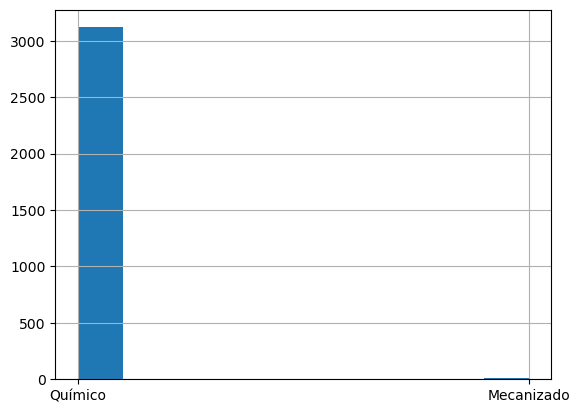

In [28]:
'''
 Se filtra el dataset controls con los IDs  de Eventos unicos pertenecientes a dicho departamento (Cordoba)
'''
controls = controls[controls.ID_EVENTO.isin(Lista_IDEvento_Unicos_cordoba)]
print("Cantidad de registro de controles filtrados de acuerdo al ID Evento: ", len(controls))
# Total de registros del archivo
print("Total de registros: ",controls.shape)
# Diagrama de frecuencias del tipo de control
controls.TIPO_CONTROL.hist()

**Nota** La mayoria de controles aplicados a cada uno de los eventos de cultivo son Quimicos, hay pocos controles mecanizados.

In [29]:
# Resumen del dataset controls
# ==================================
controls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3128 entries, 45 to 7395
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID_EVENTO        3128 non-null   int64 
 1   ID_PROD          3128 non-null   int64 
 2   FECHA_CONTROL    3128 non-null   object
 3   TIPO_OBJETIVO    3128 non-null   object
 4   TIPO_CONTROL     3128 non-null   object
 5   MOLECULA_ACTIVA  3119 non-null   object
dtypes: int64(2), object(4)
memory usage: 171.1+ KB


In [30]:
# Eliminar los registros duplicados
controls_duplicados = controls.copy()
controls_duplicados.duplicated()
# Si solamente tienen diferente el ID no se eliminan
controls_duplicados= controls_duplicados.drop_duplicates()
# Aqui se elimina 2 duplicados Unicmanete
controls_duplicados.shape

(3126, 6)

In [31]:
# Eliminamos los duplicados  teniendo en cuenta la variable Original
controls = controls.drop_duplicates()
controls.shape

(3126, 6)

In [32]:
# Se eliminan las tildes asociadas a la variable Tipos Control
controls.TIPO_CONTROL = controls.TIPO_CONTROL.apply(lambda x: x.replace("í","i"))
controls.TIPO_CONTROL


45      Quimico
46      Quimico
47      Quimico
48      Quimico
49      Quimico
         ...   
7391    Quimico
7392    Quimico
7393    Quimico
7394    Quimico
7395    Quimico
Name: TIPO_CONTROL, Length: 3126, dtype: object

In [33]:
controls

,ID_EVENTO,ID_PROD,FECHA_CONTROL,TIPO_OBJETIVO,TIPO_CONTROL,MOLECULA_ACTIVA
45,53,13,6/6/2013,Plagas,Quimico,Cipermetrina
46,53,13,6/11/2013,Malezas,Quimico,Glifosato
47,54,14,6/29/2013,Plagas,Quimico,Cipermetrina
48,54,14,6/25/2013,Malezas,Quimico,Glifosato
49,56,15,6/5/2013,Malezas,Quimico,Glifosato
...,...,...,...,...,...,...
7391,4673,4785,6/3/2016,Malezas,Quimico,GLUFOSINATO DE AMONIO
7392,4674,4784,6/3/2016,Plagas,Quimico,SPINETORAM
7393,4674,4784,6/9/2016,Malezas,Quimico,GLUFOSINATO DE AMONIO
7394,4675,4784,6/5/2016,Plagas,Quimico,SPINETORAM


In [34]:
# Ref: https://towardsdatascience.com/apply-and-lambda-usage-in-pandas-b13a1ea037f7


''' Se crea una nueva columna denominada ContTip, alamacena tipos de datos String
    Esta columna la siguiente estructura:
    - Cont + "3 primeras letras del valor de la columnas TIPO_OBJETIVO + 3 primeras letras del valor de la columna TIPO_CONTROL"
'''


# Funcion para concatenar Strings y generar la nueva columnas ConTip

def funcionConcatenarTexto(cadena1,cadena2):
    nuevacadena = "cont"+cadena1[0:3]+cadena2[0:3]
    return nuevacadena


controls["ContTip"] = controls.apply(lambda x: funcionConcatenarTexto(x.TIPO_OBJETIVO,x.TIPO_CONTROL),axis=1)


In [94]:
# Verificacion de la nueva transformación
controls.ContTip

45      contPlaQui
46      contMalQui
47      contPlaQui
48      contMalQui
49      contMalQui
           ...    
7391    contMalQui
7392    contPlaQui
7393    contMalQui
7394    contPlaQui
7395    contMalQui
Name: ContTip, Length: 3126, dtype: object

In [35]:
''' 
Se genera una tabla donde por cada valor de la columna id_evento se observa el
numero de repeticiones en los valores encontrados en la columna ContTip.

Dicho de otro modo: cantidad de controles realizados por cada ( objetivo y tipo) para cada cultivo  '''

cont = pd.crosstab(index=controls.ID_EVENTO, columns=controls.ContTip)
cont

ContTip,contEnfQui,contMalMec,contMalQui,contPlaQui
ID_EVENTO,,,,
53,0,0,1,1
54,0,0,1,1
56,0,0,1,0
57,0,0,2,0
273,0,0,1,1
...,...,...,...,...
4671,0,0,1,2
4672,0,0,1,2
4673,0,0,1,2


In [36]:
# Resumen del nuevo datset
# =========================
cont.describe()

ContTip,contEnfQui,contMalMec,contMalQui,contPlaQui
count,836.000000,836.000000,836.000000,836.000000
mean,0.167464,0.010766,1.637560,1.923445
std,0.435759,0.114270,0.909814,1.400214
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000
50%,0.000000,0.000000,2.000000,2.000000
75%,0.000000,0.000000,2.000000,2.000000
max,3.000000,2.000000,5.000000,12.000000


In [37]:
# Tranformación de FECHA CONTROL A formato date_time
controls.FECHA_CONTROL = pd.to_datetime(controls.FECHA_CONTROL,infer_datetime_format=True)


C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\324416353.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  controls.FECHA_CONTROL = pd.to_datetime(controls.FECHA_CONTROL,infer_datetime_format=True)


In [38]:
'''
Se adiciona al dataframe controls las columnas que contienen información de
fechas de siembra, emergencia, floracion y cosecha de los cultivos'''

controlesEnEventos = pd.merge(eventosParaFechas,controls, how='left',on="ID_EVENTO")
controlesEnEventos

,ID_EVENTO,ID_LOTE,FECHA_SIEMBRA,FECHA_EMERGENCIA,FECHA_COSECHA,FECHA_FLORACION,ID_PROD,FECHA_CONTROL,TIPO_OBJETIVO,TIPO_CONTROL,MOLECULA_ACTIVA,ContTip
0,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-06-06,Plagas,Quimico,Cipermetrina,contPlaQui
1,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-06-11,Malezas,Quimico,Glifosato,contMalQui
2,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-29,Plagas,Quimico,Cipermetrina,contPlaQui
3,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-25,Malezas,Quimico,Glifosato,contMalQui
4,56,44,2013-05-12,2013-05-17,2013-09-19,2013-07-15,15.0,2013-06-05,Malezas,Quimico,Glifosato,contMalQui
...,...,...,...,...,...,...,...,...,...,...,...,...
3167,4673,4321,2016-05-07,2016-05-12,2016-09-23,2016-07-02,4785.0,2016-06-03,Malezas,Quimico,GLUFOSINATO DE AMONIO,contMalQui
3168,4674,4320,2016-05-09,2016-05-15,2016-09-21,2016-07-03,4784.0,2016-06-03,Plagas,Quimico,SPINETORAM,contPlaQui
3169,4674,4320,2016-05-09,2016-05-15,2016-09-21,2016-07-03,4784.0,2016-06-09,Malezas,Quimico,GLUFOSINATO DE AMONIO,contMalQui
3170,4675,4319,2016-05-09,2016-05-14,2016-09-21,2016-07-05,4784.0,2016-06-05,Plagas,Quimico,SPINETORAM,contPlaQui


In [39]:
# Se grafican los 4 tipos de controles del datafame Controls 
# =================================================================
df = px.data.tips()
fig = px.histogram(controlesEnEventos, x="ContTip")
fig.show()


In [454]:
# Funciones de prueba previamnete desarrolladas
'''
def funcion11(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contPlaQuí":
        return 1
    else:
        return 0

def funcion22(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contMalQuí":
        return 1
    else:
        return 0
'''


'\ndef funcion11(x):\n    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contPlaQuí":\n        return 1\n    else:\n        return 0\n\ndef funcion22(x):\n    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contMalQuí":\n        return 1\n    else:\n        return 0\n'

In [40]:
# Funciones Utilizadas para la generación de las nuevas columnas
# =============================================================================================


# Numero de Controles Enfoque Quimico para cada una de las Etapas [Siembra-Emergencia -Floración-Cosecha]

def funcion1(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contEnfQui":
        return 1
    else:
        return 0


def funcion2(x):
    if ((x.FECHA_CONTROL < x.FECHA_EMERGENCIA) and (x.FECHA_CONTROL >= x.FECHA_SIEMBRA) and x.ContTip == "contEnfQui"):
        return 1
    else:
        return 0


def funcion3(x):
    if ((x.FECHA_CONTROL < x.FECHA_FLORACION) and (x.FECHA_CONTROL >= x.FECHA_EMERGENCIA) and x.ContTip == "contEnfQui"):
        return 1
    else:
        return 0


def funcion4(x):
    if ((x.FECHA_CONTROL <= x.FECHA_COSECHA) and (x.FECHA_CONTROL >= x.FECHA_FLORACION) and x.ContTip == "contEnfQui"):
        return 1
    else:
        return 0

In [41]:
# Numero de Controles Malezas Mecanizado para cada una de las Etapas [Siembra - Emergencia - Floración -Cosecha]

def funcion5(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contMalMec":
        return 1
    else:
        return 0


def funcion6(x):
    if ((x.FECHA_CONTROL < x.FECHA_EMERGENCIA) and (x.FECHA_CONTROL >= x.FECHA_SIEMBRA) and x.ContTip == "contMalMec"):
        return 1
    else:
        return 0


def funcion7(x):
    if ((x.FECHA_CONTROL < x.FECHA_FLORACION) and (x.FECHA_CONTROL >= x.FECHA_EMERGENCIA) and x.ContTip == "contMalMec"):
        return 1
    else:
        return 0


def funcion8(x):
    if ((x.FECHA_CONTROL <= x.FECHA_COSECHA) and (x.FECHA_CONTROL >= x.FECHA_FLORACION) and x.ContTip == "contMalMec"):
        return 1
    else:
        return 0


In [42]:
# Numero de Control Malezas Quimico para cada una de las Etapas [Siembra - Emergencia - Floración -Cosecha]

def funcion9(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contMalQuí":
        return 1
    else:
        return 0


def funcion10(x):
    if ((x.FECHA_CONTROL < x.FECHA_EMERGENCIA) and (x.FECHA_CONTROL >= x.FECHA_SIEMBRA) and x.ContTip == "contMalQui"):
        return 1
    else:
        return 0


def funcion11(x):
    if ((x.FECHA_CONTROL < x.FECHA_FLORACION) and (x.FECHA_CONTROL >= x.FECHA_EMERGENCIA) and x.ContTip == "contMalQui"):
        return 1
    else:
        return 0


def funcion12(x):
    if ((x.FECHA_CONTROL <= x.FECHA_COSECHA) and (x.FECHA_CONTROL >= x.FECHA_FLORACION) and x.ContTip == "contMalQui"):
        return 1
    else:
        return 0


In [43]:
# Numero de  Control Plagas Quimico para cada una de las Etapas [Siembra - Emergencia - Floración -Cosecha]

def funcion13(x):
    if (x.FECHA_CONTROL < x.FECHA_SIEMBRA) and  x.ContTip == "contPlaQuí":
        return 1
    else:
        return 0


def funcion14(x):
    if ((x.FECHA_CONTROL < x.FECHA_EMERGENCIA) and (x.FECHA_CONTROL >= x.FECHA_SIEMBRA) and x.ContTip == "contPlaQui"):
        return 1
    else:
        return 0


def funcion15(x):
    if ((x.FECHA_CONTROL < x.FECHA_FLORACION) and (x.FECHA_CONTROL >= x.FECHA_EMERGENCIA) and x.ContTip == "contPlaQui"):
        return 1
    else:
        return 0


def funcion16(x):
    if ((x.FECHA_CONTROL <= x.FECHA_COSECHA) and (x.FECHA_CONTROL >= x.FECHA_FLORACION) and x.ContTip == "contPlaQui"):
        return 1
    else:
        return 0

In [44]:
# Definicion de las nuevas columnas
# Cantidade de controles para [Enfermedades, Malezas, Plagas] en c/d etapa del cultivo
# =======================================================================================


# Conteo Enfoque Quimico en todas las etapas
controlesEnEventos["ContEnfQui_Antes_Siem"]= controlesEnEventos.apply(funcion1,axis=1)
controlesEnEventos["ContEnfQui_Siem_Eme"] = controlesEnEventos.apply(funcion2,axis=1)
controlesEnEventos["ContEnfQui_Emer_Flor"] = controlesEnEventos.apply(funcion3,axis=1)
controlesEnEventos["ContEnfQui_Flor_Cose"] = controlesEnEventos.apply(funcion4,axis=1)

# Conteo Malezas Mecanizado en cada una de las Etapas
controlesEnEventos["ContMalMec_Antes_Siem"]= controlesEnEventos.apply(funcion5,axis=1)
controlesEnEventos["ContMalMec_Siem_Emer"] = controlesEnEventos.apply(funcion6,axis=1)
controlesEnEventos["ContMalMec_Emer_Flor"] = controlesEnEventos.apply(funcion7,axis=1)
controlesEnEventos["ContMalMec_Flor_Cose"] = controlesEnEventos.apply(funcion8,axis=1)

# Conteo Malezas Quimico en cada uan de las Etapas
controlesEnEventos["ContMalQui_Antes_Siem"]= controlesEnEventos.apply(funcion9,axis=1)
controlesEnEventos["ContMalQui_Siem_Emer"] = controlesEnEventos.apply(funcion10,axis=1)
controlesEnEventos["ContMalQui_Emer_Flor"] = controlesEnEventos.apply(funcion11,axis=1)
controlesEnEventos["ContMalQui_Flor_Cose"] = controlesEnEventos.apply(funcion12,axis=1)

# Conteo Plagas Quimico en cada uan de las Etapas
controlesEnEventos["ContPlaQui_Antes_Siem"]= controlesEnEventos.apply(funcion13,axis=1)
controlesEnEventos["ContPlaQui_Siem_Emer"] = controlesEnEventos.apply(funcion14,axis=1)
controlesEnEventos["ContPlaQui_Emer_Flor"] = controlesEnEventos.apply(funcion15,axis=1)
controlesEnEventos["ContPlaQui_Flor_Cose"] = controlesEnEventos.apply(funcion16,axis=1)

In [45]:
controlesEnEventos.head(4)

,ID_EVENTO,ID_LOTE,FECHA_SIEMBRA,FECHA_EMERGENCIA,FECHA_COSECHA,FECHA_FLORACION,ID_PROD,FECHA_CONTROL,TIPO_OBJETIVO,TIPO_CONTROL,MOLECULA_ACTIVA,ContTip,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose
0,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-06-06,Plagas,Quimico,Cipermetrina,contPlaQui,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-06-11,Malezas,Quimico,Glifosato,contMalQui,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-29,Plagas,Quimico,Cipermetrina,contPlaQui,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-25,Malezas,Quimico,Glifosato,contMalQui,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [46]:
ColumnasEtapasFiltro = ['ID_EVENTO',
    'ContEnfQui_Antes_Siem', 'ContEnfQui_Siem_Eme', 'ContEnfQui_Emer_Flor','ContEnfQui_Flor_Cose',
    'ContMalMec_Antes_Siem', 'ContMalMec_Siem_Emer','ContMalMec_Emer_Flor', 'ContMalMec_Flor_Cose',
    'ContMalQui_Antes_Siem','ContMalQui_Siem_Emer', 'ContMalQui_Emer_Flor', 'ContMalQui_Flor_Cose',
    'ContPlaQui_Antes_Siem', 'ContPlaQui_Siem_Emer', 'ContPlaQui_Emer_Flor','ContPlaQui_Flor_Cose'
]


#  Agrupación de la cantidad de controles para cada una de las etapas
#====================================================================================================
controlesOnlyStages = controlesEnEventos[ColumnasEtapasFiltro]
controlesPorEtapas = controlesOnlyStages.groupby(["ID_EVENTO"]).sum()
controlesPorEtapas = controlesPorEtapas.reset_index(drop=False)

In [47]:
# Vista previa del archivo controlesPorEtapas
controlesPorEtapas.head(30)

,ID_EVENTO,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose
0,53,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,54,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,56,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,57,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0
4,273,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
5,282,0,0,0,0,0,0,0,0,0,1,1,0,0,0,2,0
6,283,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
7,284,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
8,286,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
9,287,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [48]:
print("Dimensiones del dataframe Eventos cordoba: ", evento_cordoba.shape)
print("Dimenciones del dataframe Control por Etapas: ",controlesPorEtapas.shape)

Dimensiones del dataframe Eventos cordoba:  (882, 16)
Dimenciones del dataframe Control por Etapas:  (882, 17)


In [49]:

''' 

    Se realiza un merge con las columna de controles con el objetivo de contruir la vista miable

'''

eventosFinales = pd.merge(evento_cordoba,controlesPorEtapas,how='left')
print("Dimensiones del dataframe eventosFinales, despees de agregar columnas del archivo controls: ",eventosFinales.shape)


Dimensiones del dataframe eventosFinales, despees de agregar columnas del archivo controls:  (882, 32)


In [469]:
# Se realiza el gurde de los datos, una vez procesado y obtenidas las columnas de interes del dataset controls.csv
eventosFinales.to_excel("../Archivos Generados/eventos_controls.xlsx")

## PROCESAMIENTO ARCHIVO Fertilizatios_3_Miaz_limpia.csv

In [50]:
# Lectura del dataframe
# =========================================================================================================
fertilizaciones = pd.read_csv("../Data/Bronze/Fertilizations_3_Maiz_limpia.csv",sep=',',on_bad_lines='skip')
print("Longitud: ", fertilizaciones.shape)
fertilizaciones.head(5)

Longitud:  (7512, 12)


,ID_EVENTO,ID_PROD,FECHA_FERT,ID_FER_QUI,TIPO_FERTILIZACION,CANTIDAD_PROD_FERTI,PROD_QUI,PROD_ORG,PROD_ENM,N,P,K
0,24,40,2/06/2013,14,Enmiendas,1000,NaN,NaN,Cal,NaN,NaN,NaN
1,615,539,10/07/2013,624,Enmiendas,200,NaN,NaN,Cal,NaN,NaN,NaN
2,955,156,3/31/2014,1270,Enmiendas,20,NaN,NaN,Escorias,NaN,NaN,NaN
3,955,156,3/31/2014,1270,Enmiendas,40,NaN,NaN,Yeso,NaN,NaN,NaN
4,1213,1072,5/22/2014,1658,Enmiendas,750,NaN,NaN,Cal,NaN,NaN,NaN


In [51]:
fertilizaciones.columns

Index(['ID_EVENTO', 'ID_PROD', 'FECHA_FERT', 'ID_FER_QUI',
       'TIPO_FERTILIZACION', 'CANTIDAD_PROD_FERTI', 'PROD_QUI', 'PROD_ORG',
       'PROD_ENM', 'N', 'P', 'K'],
      dtype='object')

In [52]:
# Analisis general del dataset
fertilizaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7512 entries, 0 to 7511
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_EVENTO            7512 non-null   int64  
 1   ID_PROD              7512 non-null   int64  
 2   FECHA_FERT           7512 non-null   object 
 3   ID_FER_QUI           7512 non-null   int64  
 4   TIPO_FERTILIZACION   7512 non-null   object 
 5   CANTIDAD_PROD_FERTI  7512 non-null   int64  
 6   PROD_QUI             7372 non-null   object 
 7   PROD_ORG             112 non-null    object 
 8   PROD_ENM             28 non-null     object 
 9   N                    7319 non-null   float64
 10  P                    7287 non-null   float64
 11  K                    7304 non-null   float64
dtypes: float64(3), int64(4), object(5)
memory usage: 704.4+ KB


In [53]:
# Analisis de nulos de dataset
fertilizaciones.isnull().sum()

ID_EVENTO                 0
ID_PROD                   0
FECHA_FERT                0
ID_FER_QUI                0
TIPO_FERTILIZACION        0
CANTIDAD_PROD_FERTI       0
PROD_QUI                140
PROD_ORG               7400
PROD_ENM               7484
N                       193
P                       225
K                       208
dtype: int64

In [54]:
# Analisis de variable tipo de fertilizacion.
# =================================================
df = px.data.tips()
fig = px.histogram(fertilizaciones, x="TIPO_FERTILIZACION")
fig.show()


*Nota:* La mayoria de fertilizaciones son quimicas , los otros tipos: Enmiendas y Organica tienen asociadas muy pocos registros.

In [55]:
# Se filtra unicamente fertilización correspondiantes al departamento de cordoba
# =================================================================================================
fertilizaciones = fertilizaciones[fertilizaciones.ID_EVENTO.isin(Lista_IDEvento_Unicos_cordoba)]
print("Cantidad de registros de Fertilizaciones asociadas a los eventos de cultivo referentes a Cordoba al ID Evento: ", len(fertilizaciones))

Cantidad de registros de Fertilizaciones asociadas a los eventos de cultivo referentes a Cordoba al ID Evento:  2258


In [56]:
# Validad que la columna CANTIDAD_PROD_FERTI sea numerica
fertilizaciones.CANTIDAD_PROD_FERTI

32        200
45         50
56      12000
57      12000
58      12000
        ...  
7498      100
7499      100
7500      100
7508      250
7509      125
Name: CANTIDAD_PROD_FERTI, Length: 2258, dtype: int64

In [57]:
# Eliminar los registros duplicados del dataset | en caso de que existan
# ======================================================================================
fertilizaciones = fertilizaciones.drop_duplicates()
print("Cantidad de registros despues de eliminar los duplicados: ", fertilizaciones.shape)


Cantidad de registros despues de eliminar los duplicados:  (2258, 12)


In [58]:
fertilizaciones.TIPO_FERTILIZACION.value_counts()

TIPO_FERTILIZACION
Quimica     2234
Organica      24
Name: count, dtype: int64

In [59]:
#  Se crea una nueva columna en el dataframe , deacuerdo al tipo de fertilización 
# ==========================================================
fertilizaciones["Fer"] = fertilizaciones.TIPO_FERTILIZACION.apply(lambda x: "CanFer"+x[0:3])
fertilizaciones.head(3)

,ID_EVENTO,ID_PROD,FECHA_FERT,ID_FER_QUI,TIPO_FERTILIZACION,CANTIDAD_PROD_FERTI,PROD_QUI,PROD_ORG,PROD_ENM,N,P,K,Fer
32,807,818,5/27/2014,1048,Organica,200,NaN,Lombri compost,NaN,NaN,NaN,NaN,CanFerOrg
45,2391,2289,6/04/2015,4270,Organica,50,NaN,Otro,NaN,NaN,NaN,NaN,CanFerOrg
56,3145,2802,8/18/2015,6321,Organica,12000,NaN,Estiercol,NaN,NaN,NaN,NaN,CanFerOrg


In [60]:
# Cantidad de Fertilizaciones hechas por cada tipo de Siembra
frecFer = pd.crosstab(index=fertilizaciones.ID_EVENTO, columns=fertilizaciones.Fer).reset_index(drop=False)
frecFer

Fer,ID_EVENTO,CanFerOrg,CanFerQui
0,53,0,1
1,54,0,2
2,56,0,1
3,57,0,1
4,273,0,1
...,...,...,...
874,4671,0,3
875,4672,0,4
876,4673,0,4
877,4674,0,4


In [61]:
# Se cambia el formato de cada uno de los nutrientes (N,P,K) |verificar
# En este caso ya se encuentran en el formato establecido
fertilizaciones.K.head(5)

32   NaN
45   NaN
56   NaN
57   NaN
58   NaN
Name: K, dtype: float64

In [62]:
# Se verifica que la variable Fecha de Fertilización efectivamente este en el formato DateTime
fertilizaciones.FECHA_FERT = pd.to_datetime(fertilizaciones.FECHA_FERT,infer_datetime_format=True)
fertilizaciones.FECHA_FERT.head(5)

C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\2166305443.py:2: UserWarning:

The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.



32   2014-05-27
45   2015-06-04
56   2015-08-18
57   2015-08-21
58   2015-08-17
Name: FECHA_FERT, dtype: datetime64[ns]

In [63]:
# Se realiza un merge entre [Eventos para fechas y fertilizaciones | ID EVENTO]
fertilizacionesEnEventos = pd.merge(eventosParaFechas,fertilizaciones,how='left',on=['ID_EVENTO'])
print("Tamaño Eventos Fertilizaciones: ", fertilizacionesEnEventos.shape)
fertilizacionesEnEventos.head(5)

Tamaño Eventos Fertilizaciones:  (2261, 18)


,ID_EVENTO,ID_LOTE,FECHA_SIEMBRA,FECHA_EMERGENCIA,FECHA_COSECHA,FECHA_FLORACION,ID_PROD,FECHA_FERT,ID_FER_QUI,TIPO_FERTILIZACION,CANTIDAD_PROD_FERTI,PROD_QUI,PROD_ORG,PROD_ENM,N,P,K,Fer
0,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-05-28,956.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui
1,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-05-20,146.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui
2,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-04,147.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui
3,56,44,2013-05-12,2013-05-17,2013-09-19,2013-07-15,15.0,2013-06-04,36.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui
4,57,45,2013-05-07,2013-05-12,2013-09-12,2013-07-15,16.0,2013-05-22,148.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui


In [73]:
# Conteo especifico de la categoria FER
fertilizacionesEnEventos.Fer.value_counts()

Fer
CanFerQui    2234
CanFerOrg      24
Name: count, dtype: int64

In [74]:
'''
Funcion (Fertilizaciones) para c/u de las columnas [organica Quimica]
Conteo del Numero de fertilizaciónes [Organicas o quimicas] realizadas en c/d fase del cultivo
En este caso solo se tienen en ceunta las siguientes fases:
 - Antes de la siembra
 - Siembra a emergencia
 - Emergencia a Floración

No se tienen en ceunta las fertilizaciones de floración- cosecha , dado que estas estas fases
el cultivo ya no tiene fertilizaciones registradas

Entrada: x: DataFrame 

'''

# Para las fertilizaciones Organicas
# ====================================================================================
def funcFertOrg1(x):
    if (x.FECHA_FERT < x.FECHA_SIEMBRA) and x.Fer == "CanFerOrg":
        return 1
    else:
        return 0

def funcFertOrg2(x):
    if (x.FECHA_FERT < x.FECHA_EMERGENCIA) and (x.FECHA_FERT  >= x.FECHA_SIEMBRA) and x.Fer=="CanFerOrg":
        return 1
    else:
        return 0

def funcFertOrg3(x):
    if (x.FECHA_FERT <= x.FECHA_COSECHA) and (x.FECHA_FERT  >= x.FECHA_EMERGENCIA) and (x.Fer == "CanFerOrg"):
        return 1
    else:
        return 0


# Para las Fetilizaciones Quimicas
# =====================================================================================================
def funcFertQui1(x):
    if (x.FECHA_FERT < x.FECHA_SIEMBRA) and x.Fer == "CanFerQui":
        return 1
    else:
        return 0


def funcFertQui2(x):
    if (x.FECHA_FERT < x.FECHA_EMERGENCIA) and (x.FECHA_FERT >= x.FECHA_SIEMBRA) and x.Fer=="CanFerQui":
        return 1
    else:
        return 0


def funcFertQui3(x):
    if (x.FECHA_FERT <= x.FECHA_COSECHA) and (x.FECHA_FERT  >= x.FECHA_EMERGENCIA) and (x.Fer == "CanFerQui"):
        return 1
    else:
        return 0

In [66]:
# Fertilizaciones Organicas para cada una de las etapas
# ================================================================================
fertilizacionesEnEventos["FerOrg_Antes_Siem"] = fertilizacionesEnEventos.apply(funcFertOrg1,axis=1)
fertilizacionesEnEventos["FerOrg_Siem_Emer"] = fertilizacionesEnEventos.apply(funcFertOrg2,axis=1)
fertilizacionesEnEventos["FerOrg_Emer_Flor"] = fertilizacionesEnEventos.apply(funcFertOrg3,axis=1)

In [67]:
# Fertilizaciones Quimicas para cada una de las etapas
# =================================================================================
fertilizacionesEnEventos["FerQui_Antes_Siem"] = fertilizacionesEnEventos.apply(funcFertQui1,axis=1)
fertilizacionesEnEventos["FerQui_Siem_Emer"] = fertilizacionesEnEventos.apply(funcFertQui2,axis=1)
fertilizacionesEnEventos["FerQui_Emer_Flor"] = fertilizacionesEnEventos.apply(funcFertQui3,axis=1)


In [68]:
fertilizacionesEnEventos

,ID_EVENTO,ID_LOTE,FECHA_SIEMBRA,FECHA_EMERGENCIA,FECHA_COSECHA,FECHA_FLORACION,ID_PROD,FECHA_FERT,ID_FER_QUI,TIPO_FERTILIZACION,CANTIDAD_PROD_FERTI,PROD_QUI,PROD_ORG,PROD_ENM,N,P,K,Fer,FerOrg_Antes_Siem,FerOrg_Siem_Emer,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor
0,53,40,2013-05-13,2013-05-18,2013-09-26,2013-07-20,13.0,2013-05-28,956.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui,0,0,0,0,0,1
1,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-05-20,146.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui,0,0,0,0,0,1
2,54,43,2013-05-02,2013-05-07,2013-09-11,2013-07-10,14.0,2013-06-04,147.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui,0,0,0,0,0,1
3,56,44,2013-05-12,2013-05-17,2013-09-19,2013-07-15,15.0,2013-06-04,36.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui,0,0,0,0,0,1
4,57,45,2013-05-07,2013-05-12,2013-09-12,2013-07-15,16.0,2013-05-22,148.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2256,4674,4320,2016-05-09,2016-05-15,2016-09-21,2016-07-03,4784.0,2016-06-16,9522.0,Quimica,50.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui,0,0,0,0,0,1
2257,4674,4320,2016-05-09,2016-05-15,2016-09-21,2016-07-03,4784.0,2016-06-28,9523.0,Quimica,50.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui,0,0,0,0,0,1
2258,4675,4319,2016-05-09,2016-05-14,2016-09-21,2016-07-05,4784.0,2016-06-14,9525.0,Quimica,50.0,KCl,NaN,NaN,0.0,0.0,60.0,CanFerQui,0,0,0,0,0,1
2259,4675,4319,2016-05-09,2016-05-14,2016-09-21,2016-07-05,4784.0,2016-05-30,9524.0,Quimica,100.0,Urea,NaN,NaN,46.0,0.0,0.0,CanFerQui,0,0,0,0,0,1


In [75]:
'''
- La cantidad de Suplementos quimicos asociada a cada uno de los lotes viene en kg/Ha 

'''
# Cantidad de fertilizaciones [ORGANICA Y QUIMICA] aplicadas en c/u de las etapas del cultivo.
# ================================================================================================
columnasFertilizaciones = ['ID_EVENTO','FerOrg_Antes_Siem','FerOrg_Siem_Emer', 'FerOrg_Emer_Flor'
                            ,'FerQui_Antes_Siem', 'FerQui_Siem_Emer', 'FerQui_Emer_Flor'] 

fertilizationByStages = fertilizacionesEnEventos[columnasFertilizaciones]
fertilizacionesPorEtapa = fertilizationByStages.groupby(["ID_EVENTO"]).sum().reset_index(drop=False)
fertilizacionesPorEtapa

,ID_EVENTO,FerOrg_Antes_Siem,FerOrg_Siem_Emer,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor
0,53,0,0,0,0,0,1
1,54,0,0,0,0,0,2
2,56,0,0,0,0,0,1
3,57,0,0,0,0,0,1
4,273,0,0,0,0,0,1
...,...,...,...,...,...,...,...
877,4671,0,0,0,0,0,3
878,4672,0,0,0,0,0,4
879,4673,0,0,0,0,0,4
880,4674,0,0,0,0,0,4


In [76]:
fertilizaciones.columns

Index(['ID_EVENTO', 'ID_PROD', 'FECHA_FERT', 'ID_FER_QUI',
       'TIPO_FERTILIZACION', 'CANTIDAD_PROD_FERTI', 'PROD_QUI', 'PROD_ORG',
       'PROD_ENM', 'N', 'P', 'K', 'Fer'],
      dtype='object')

In [77]:
# Ahora lo que se intenta hacer es buscar la cantidad de fertilizaciones quimicas [n,p,k] realizadas por cada una de las
# Etapas del cultivo [Siembra - Emergencia - Floración - Cosecha]
# Funcion para aplicar apply teniendo en cuenta el tipo de fertilización en cada uan de las fases del cultivo
# [Siembra - Emergencia - Floracion - Cosecha]
# X: DataFrame


# Funciones para el nitrogeno (N)
# ===================================================================================
def funcN1(x):
    if (x.FECHA_FERT <  x.FECHA_SIEMBRA) and (x.Fer == "CanFerQui"):
        op = (x.N/100)*(x.CANTIDAD_PROD_FERTI)
        return (op)
    else:
        return 0

def funcN2(x):
    if (x.FECHA_FERT < x.FECHA_EMERGENCIA) and (x.FECHA_FERT  >= x.FECHA_SIEMBRA) and (x.Fer == "CanFerQui"):
        op = (x.N/100)*(x.CANTIDAD_PROD_FERTI)
        return op
    else:
        return 0


def funcN3(x):
    if (x.FECHA_FERT <= x.FECHA_COSECHA) and (x.FECHA_FERT  >= x.FECHA_EMERGENCIA) and (x.Fer == "CanFerQui"):
        op = (x.N/100)*(x.CANTIDAD_PROD_FERTI)
        return op
    else:
        return 0

# Funciones para el Fosforo (P)
# ===================================================================================

def funcP1(x):
    if (x.FECHA_FERT < x.FECHA_SIEMBRA) and (x.Fer == "CanFerQui"):
        op = (x.P/100)*(x.CANTIDAD_PROD_FERTI)
        return op
    else:
        return 0

def funcP2(x):
    if (x.FECHA_FERT < x.FECHA_EMERGENCIA) and (x.FECHA_FERT  >= x.FECHA_SIEMBRA) and (x.Fer == "CanFerQui"):
        op = (x.P/100)*(x.CANTIDAD_PROD_FERTI)
        return op
    else:
        return 0

def funcP3(x):
    if (x.FECHA_FERT <= x.FECHA_COSECHA) and (x.FECHA_FERT  >= x.FECHA_EMERGENCIA) and (x.Fer == "CanFerQui"):
        op = (x.P/100)*(x.CANTIDAD_PROD_FERTI)
        return op
    else:
        return 0


# Funciones para el poteacio (K)
# ============================================================================================================0

def funcK1(x):
    if (x.FECHA_FERT < x.FECHA_SIEMBRA) and (x.Fer == "CanFerQui"):
        op = (x.K/100)*(x.CANTIDAD_PROD_FERTI)
        return op
    else:
        return 0 

def funck2(x):
    if (x.FECHA_FERT < x.FECHA_EMERGENCIA) and (x.FECHA_FERT  >= x.FECHA_SIEMBRA) and (x.Fer == "CanFerQui"):
        op = op = (x.K/100)*(x.CANTIDAD_PROD_FERTI)
        return op
    else:
        return 0

def funcK3(x):
    if (x.FECHA_FERT <= x.FECHA_COSECHA) and (x.FECHA_FERT  >= x.FECHA_EMERGENCIA) and (x.Fer == "CanFerQui"):
        op = op = (x.K/100)*(x.CANTIDAD_PROD_FERTI)
        return op
    else:
        return 0


In [72]:
#  na.rm = TRUE  en R-Estudio se utiliza para excluir valores faltantes cuando
# se desea calcular una estadistica descriprtivas
fertilizacionesEnEventos['TotN_Antes_Siem'] = fertilizacionesEnEventos.apply(funcN1,axis=1)
fertilizacionesEnEventos['TotN_Siem_Emer'] = fertilizacionesEnEventos.apply(funcN2,axis=1)
fertilizacionesEnEventos['TotN_Emer_Flor'] = fertilizacionesEnEventos.apply(funcN3,axis=1)
fertilizacionesEnEventos['TotP_Antes_Siem'] = fertilizacionesEnEventos.apply(funcP1,axis=1)
fertilizacionesEnEventos['TotP_Siem_Emer'] = fertilizacionesEnEventos.apply(funcP2,axis=1)
fertilizacionesEnEventos['TotP_Emer_Flor'] = fertilizacionesEnEventos.apply(funcP3,axis=1)
fertilizacionesEnEventos['TotK_Antes_Siem'] = fertilizacionesEnEventos.apply(funcK1, axis=1)
fertilizacionesEnEventos['TotK_Siem_Emer'] = fertilizacionesEnEventos.apply(funck2,axis=1)
fertilizacionesEnEventos['TotK_Emer_Flor'] = fertilizacionesEnEventos.apply(funcK3,axis=1)

In [81]:
# Se obtienen las nuevas columnas para realizar el filtro
columnasFertilizacionQuimicasNPK = [ 'ID_EVENTO', 'TotN_Antes_Siem','TotN_Siem_Emer', 'TotN_Emer_Flor',
                                    'TotP_Antes_Siem', 'TotP_Siem_Emer','TotP_Emer_Flor',
                                    'TotK_Antes_Siem', 'TotK_Siem_Emer','TotK_Emer_Flor']

In [82]:
# Generacion nuevo datframe con als fertilizaciones x etpapa para cada evento
# =======================================================================================
fertbySrage = fertilizacionesEnEventos[columnasFertilizacionQuimicasNPK]
fertilizacionesQimicasPorEtapa = fertbySrage.groupby(["ID_EVENTO"]).sum().reset_index(drop=False)
print("Dimensiones: ", fertilizacionesQimicasPorEtapa.shape)
fertilizacionesQimicasPorEtapa.head(20)

Dimensiones:  (882, 10)


,ID_EVENTO,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor
0,53,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0
1,54,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0
2,56,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0
3,57,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0
4,273,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0
5,282,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0
6,283,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0
7,284,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0
8,286,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0
9,287,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0


In [83]:
# Analisis de frecuencia de cada uno de los productos Organicos
fertilizaciones.PROD_ORG.value_counts()

PROD_ORG
Estiercol         22
Lombri compost     1
Otro               1
Name: count, dtype: int64

In [84]:
# Finalmente se obtienen las variables relacionadas a las fertilizaciones que hacen referencia:
# Numero total de fertilizaciones [Quimicas - Organicas] x evento en c/u de las etapas
# Cantidad total de Quimicos  [N,P,K] aplicados a cada evento, en cada una de las etapas del cultivo

VariablesDeFertilizaciones = pd.merge(fertilizacionesQimicasPorEtapa,fertilizacionesPorEtapa , how='inner')
print("Dimensiones: ", VariablesDeFertilizaciones.shape)
VariablesDeFertilizaciones.head(5)

Dimensiones:  (882, 16)


,ID_EVENTO,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Antes_Siem,FerOrg_Siem_Emer,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor
0,53,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
1,54,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2
2,56,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
3,57,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
4,273,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1


In [85]:
# Finalmente se realiza el merge con los eventos fianales y se incluye la parte de Fertilizaciones
eventosFinales = pd.merge(eventosFinales,VariablesDeFertilizaciones, how='inner')

In [86]:
# El numero de columnas coinciden - menos registros
eventosFinales

,ID_EVENTO,ID_LOTE,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,AREA,RDT_AJUSTADO,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Antes_Siem,FerOrg_Siem_Emer,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor
0,53,40,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,4767.441860,5.0,63.0,68.0,60000.0,13,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
1,54,43,Mecanizado,SI,DK 234,Maiz,SI,Manual,NO,1.0,4651.162791,5.0,64.0,63.0,60000.0,15,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2
2,56,44,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,5180.232558,5.0,59.0,66.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
3,57,45,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,4897.674419,5.0,64.0,59.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
4,273,46,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,5302.325581,5.0,63.0,60.0,60000.0,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,4671,4323,Manual,NO,Otro,Maiz,SI,Manual,NO,1.0,6900.581395,4.0,49.0,83.0,64200.0,18,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,0.0,0.0,69.0,0.0,0.0,0.0,0.0,0.0,30.0,0,0,0,0,0,3
878,4672,4322,Mecanizado,NO,Otro,Maiz,SI,Mecanizada,NO,2.1,5983.720930,6.0,49.0,84.0,60000.0,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,0.0,0.0,61.0,0.0,0.0,15.0,0.0,0.0,45.0,0,0,0,0,0,4
879,4673,4321,Mecanizado,NO,Otro,Algodón,NO,Mecanizada,NO,2.0,6105.325581,5.0,51.0,83.0,59800.0,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,0,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,30.0,0,0,0,0,0,4
880,4674,4320,Mecanizado,NO,DK 234 YGRR,Algodón,SI,Mecanizada,NO,2.2,6216.279070,6.0,49.0,80.0,70000.0,17,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,30.0,0,0,0,0,0,4


In [503]:
# Una vez procesado el archivo de fertelizacions de añdade la nueva información al erchivo de controles.
eventosFinales.to_excel("../Archivos Generados/eventos_Fetilizations.xlsx")

## PROCESAMIENTO DEL ARCHIVO RASTA.CSV

In [88]:
# Lectura del archivo- Origen
# ===================================================================================
rastas = pd.read_csv("../Data/bronze/rasta_maiz_con_inferidas.csv",encoding='latin-1')
rastas.head(5)

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo
0,8,11,1.0,PLANO O LLANO,PLANO,2,"7,63","0,0","31,23","FAr,FAr","PLASTICO,PLASTICO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,SI,0.0,0.0,0.0,SI,0.0,0.0,SI,50.0,NO,GRANULAR,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,NO,NaN,POCO AFECTADAS,NO,NO,NO,NO,BUENO,0,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO
1,9,12,1.0,PLANO O LLANO,PLANO,2,"41,29","4,26","4,26","ArL,FAr","MUY PLASTICO,PLASTICO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,SI,0.0,0.0,0.0,SI,0.0,0.0,SI,56.0,NO,SIN ESTRUCTURA,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,SI,42.0,PLANTAS NORMALES,NO,NO,NO,NO,BUENO,42,"BAJA,BAJA",BUENO,NINGUNO
2,10,13,1.0,PLANO O LLANO,PLANO,2,"40,30","10,18","6,18","FAr,FAr","MUY PLASTICO,PLASTICO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,SI,0.0,0.0,0.0,SI,0.0,0.0,SI,50.0,NO,SIN ESTRUCTURA,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,SI,55.0,PLANTAS NORMALES,NO,NO,NO,NO,MUY BUENO,55,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO
3,12,15,1.0,PLANO O LLANO,PLANO,2,"47,23","18,1","18,1","Ar,A","MUY PLASTICO,MUY PLASTICO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,0.0,0.0,SI,47.0,NO,ATERRONADA,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,SI,47.0,PLANTAS NORMALES,NO,NO,NO,NO,BUENO,47,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO
4,13,16,2.0,ONDULADO,PLANO,4,"21,22,11,13","10,10,10,10","6,18,18,18","FA,FAr,A,FAr","FIRME,FRIABLE,FRIABLE,FRIABLE",6.0,NO TIENE,NaN,PEDREGOSO,SIN ROCAS,PEDREGOSO,SIN ROCAS,SI,2.0,21.0,1.0,SI,2.0,21.0,SI,54.0,NO,MASIVA,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,SI,54.0,PLANTAS NORMALES,NO,NO,NO,NO,SIN COBERTURA,54,"BAJA,BAJA,MEDIA,BAJA",BUENO,NINGUNO


In [90]:
# Se obtienen los IDLotes Unicos para el departamento de cordoba
# ===============================================================
Lista_ID_lotes_cordoba = list(evento_cordoba.ID_LOTE.unique())
print("Numero de lotes unicos del departamento de Cordoba :",len(Lista_ID_lotes_cordoba))

Numero de lotes unicos del departamento de Cordoba : 882


In [94]:
# Se filtra los registros rasta unicamente para el departamento de Cordoba
# =======================================================================================
Lista_ID_lotes_cordoba
rastasCordoba = rastas[rastas.ID_LOTE.isin(Lista_ID_lotes_cordoba)].reset_index(drop=True)
print(rastasCordoba.shape)
rastasCordoba.head() 

(810, 48)


,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo
0,40,42,2.0,PLANO O LLANO,PLANO,3,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,NaN,NaN,SI,31.0,NO,GRANULAR,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,NO,NaN,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO
1,43,43,1.0,PLANO O LLANO,PLANO,3,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,NO,NaN,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO
2,44,44,1.0,PLANO O LLANO,PLANO,3,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO
3,45,45,2.0,PLANO O LLANO,PLANO,3,"16,39,29","4,18,31","9,44,34","FAr,FrL,FrL","BLANDO,BLANDO,BLANDO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,22.0,1.5,SI,11.0,NO,GRANULAR,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,NO,NaN,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,11,"BAJA,NA,NA",LENTO A MUY LENTO,NINGUNO
4,46,46,2.0,PLANO O LLANO,PLANO,3,"33,6,47","8,32,35","16,34,38","FAr,FAr,FrL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,19.0,1.7,SI,6.0,NO,GRANULAR,NO,NO,NO HAY,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,NO,NaN,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,6,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO


In [97]:
# Ahi unicamente 804 registros ID unicos
len(rastasCordoba.ID_LOTE.unique())

804

In [101]:
# En este caso no se elimina ningun registro dado que analizando la información no son registros duplicados
rastasCordoba.ID_LOTE.value_counts().head(10)


ID_LOTE
2937    2
3675    2
3016    2
479     2
670     2
717     2
3642    1
3643    1
3644    1
3667    1
Name: count, dtype: int64

In [102]:
# Eliminamos las filas duplicadas del dataframe
# No existen ninguna fila duplicada..
rastasCordoba[rastasCordoba.duplicated()]

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo


In [103]:
# Comprobacion de que realmente se filtro por los lotes correctos
rastasCordoba[rastasCordoba.ID_LOTE==2937]

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo
457,2937,2811,1.0,PLANO O LLANO,PLANO,2,"26,34","10,49","7,44","Ar,FAr","DURO,BLANDO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,NaN,NaN,SI,27.0,NO,GRANULAR,NO,NO,POCO MARCADAS,LA MAÑANA Y LA TARDE,POCO MARCADAS,NO HAY,NO,SI,17.0,PLANTAS NORMALES,NO,NO,SI,NO,BUENO,27,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO
458,2937,2811,2.0,PLANO O LLANO,PLANO,2,"27,33","10,49","2,31","Ar,F","DURO,BLANDO",5.5,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,12.0,4.0,SI,28.0,NO,GRANULAR,NO,NO,POCO MARCADAS,LA MAÑANA Y LA TARDE,NO HAY,NO HAY,NO,SI,16.0,PLANTAS NORMALES,NO,NO,SI,NO,BUENO,16,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO


In [104]:
# Verificamos qeu efectivamente no existe ninguna Fila duplicada
rastasCordoba.duplicated().value_counts()

False    810
Name: count, dtype: int64

In [513]:
# Conversion del tipo de dato y tratamiento
# Converion a caracter
''' 
rastasCordoba.TERRENO_CIRCUN_RASTA = rastasCordoba.TERRENO_CIRCUN_RASTA.apply(str)
rastasCordoba.POSICION_PERFIL_RASTA = rastasCordoba.POSICION_PERFIL_RASTA.apply(str)
rastasCordoba.SITIO_EXPUESTO_SOL_RASTA = rastasCordoba.SITIO_EXPUESTO_SOL_RASTA(str)
'''

' \nrastasCordoba.TERRENO_CIRCUN_RASTA = rastasCordoba.TERRENO_CIRCUN_RASTA.apply(str)\nrastasCordoba.POSICION_PERFIL_RASTA = rastasCordoba.POSICION_PERFIL_RASTA.apply(str)\nrastasCordoba.SITIO_EXPUESTO_SOL_RASTA = rastasCordoba.SITIO_EXPUESTO_SOL_RASTA(str)\n'

In [105]:
rastasCordoba.SITIO_EXPUESTO_SOL_RASTA.value_counts()


SITIO_EXPUESTO_SOL_RASTA
LA MAÑANA Y LA TARDE    806
LA MAÑANA                 3
LA TARDE                  1
Name: count, dtype: int64

In [106]:
# Manejo de caracteres especiales [Elimnacion de las Tildes]
# ===========================================================================
rastasCordoba.TERRENO_CIRCUN_RASTA = rastasCordoba.TERRENO_CIRCUN_RASTA.apply(lambda x: "ONDULADO Y MONTANOSO" if x=="ONDULADO Y MONTAÑOSO" else x)
rastasCordoba.POSICION_PERFIL_RASTA = rastasCordoba.POSICION_PERFIL_RASTA.apply(lambda x: "PIE DE UNA ELEVACION" if x=="PIE DE UNA ELEVACIÓN" else x)
rastasCordoba.POSICION_PERFIL_RASTA = rastasCordoba.POSICION_PERFIL_RASTA.apply(lambda x: "LADERA CONCAVA" if x=="LADERA CÓNCAVA" else x)
rastasCordoba.SITIO_EXPUESTO_SOL_RASTA = rastasCordoba.SITIO_EXPUESTO_SOL_RASTA.apply(lambda x: "LA MANANA Y LA TARDE" if x =="LA MAÑANA Y LA TARDE" else x)
rastasCordoba.SITIO_EXPUESTO_SOL_RASTA = rastasCordoba.SITIO_EXPUESTO_SOL_RASTA.apply(lambda x: "LA MANANA" if x =="LA MAÑANA" else x)


In [109]:
#  Verificación de variables y formato.
# ====================================================

rastasCordoba.POSICION_PERFIL_RASTA.value_counts()

POSICION_PERFIL_RASTA
PLANO                     780
PLANO CON ONDULACIONES     18
LADERA CONVEXA              5
LADERA PLANA                3
PIE DE UNA ELEVACION        2
LADERA CONCAVA              2
Name: count, dtype: int64

In [111]:
rastasCordoba.OBSERVA_RAICES_VIVAS_RASTA.value_counts()

OBSERVA_RAICES_VIVAS_RASTA
SI    778
NO     32
Name: count, dtype: int64

In [112]:
rastasCordoba.PROFUND_RAICES_VIVAS_RASTA

0       NaN
1       NaN
2      30.0
3       NaN
4       NaN
       ... 
805    20.0
806    27.0
807    23.0
808    31.0
809    22.0
Name: PROFUND_RAICES_VIVAS_RASTA, Length: 810, dtype: float64

In [113]:
rastasCordoba[["OBSERVA_RAICES_VIVAS_RASTA", "PROFUND_RAICES_VIVAS_RASTA"]]

,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA
0,NO,NaN
1,NO,NaN
2,SI,30.0
3,NO,NaN
4,NO,NaN
...,...,...
805,SI,20.0
806,SI,27.0
807,SI,23.0
808,SI,31.0


In [114]:
''' 
    Al aplicar el filtro anterior [OBSERVA_RAICES_VIVAS_RASTA, PROFUND_RAICES_VIVAS_RASTA]
    cuando en los registros la variable OBSERVA_RAICES_VIVAS_RASTA [NO], tien asignado NAN
    Sin mebargo cuando no hay presencia de RAICES RASTA no debe existir ningun profundidad
    por lo tanto se asigna el valor de (-1) a estos valores.

'''

rastasCordoba.PROFUND_RAICES_VIVAS_RASTA[rastasCordoba.OBSERVA_RAICES_VIVAS_RASTA=='NO'] = -1
rastasCordoba.PROFUND_CAP_ENDURE_RASTA[rastasCordoba.CAP_ENDURE_RASTA=='NO']= -1
rastasCordoba.ESPESOR_CAP_ENDURE_RASTA[rastasCordoba.CAP_ENDURE_RASTA == 'NO'] = -1
rastasCordoba.PROFUND_MOTEADOS_RASTA[rastasCordoba.CAP_ENDURE_RASTA == 'NO'] = -1


C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\3115606934.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\3115606934.py:10: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this

In [115]:
rastasCordoba.PROFUND_MOTEADOS_RASTA[rastasCordoba.CAP_ENDURE_RASTA == 'NO']

0     -1.0
14    -1.0
20    -1.0
22    -1.0
23    -1.0
      ... 
804   -1.0
805   -1.0
806   -1.0
807   -1.0
808   -1.0
Name: PROFUND_MOTEADOS_RASTA, Length: 707, dtype: float64

In [ ]:
# Verificación del tratameinto sobre estas variables
# ===================================================================
rastasCordoba.PROFUND_MOTEADOS_RASTA.unique()

array([-1., 30., 14., 11.,  6., 20., 37., 55., 50., 15., 23., 64., 26.,
       nan, 13., 35., 21., 24., 12., 25., 22., 31., 19., 18., 28., 27.])

###  Tratamiento de datos del suelo mediante la guia Rasta

En este apartado se realiza la transformación y procesamiento de la variable Textura
asociada a cada evento del cultivo. Se extrae los porcentajes de de presencia de c/u 
de las texturas.

In [ ]:
# Se crea un nuevo dataframe donde se almacenan las diferentes texturas del suelo
# =================================================================================
tablaTexturas = pd.DataFrame(["A","Ar","ArA","ArL","FrL","L","F","ArF","FAr","FA","AF"], columns=['textura'])
tablaTexturas

,textura
0,A
1,Ar
2,ArA
3,ArL
4,FrL
5,L
6,F
7,ArF
8,FAr
9,FA


In [118]:
# Procedimiento de calcular y almacenar en una lista el porcentaje 
# de cada posible textua al interior del cajon que se realiza en la guia rasta.
capas = rastasCordoba[['NO_CAPAS_RASTA','ESPESOR','TEXTURA']]
capas

,NO_CAPAS_RASTA,ESPESOR,TEXTURA
0,3,"22,9,50","FAr,FrL,FA"
1,3,"20,14,36","FAr,FAr,ArL"
2,3,"26,14,38","FAr,FAr,AF"
3,3,"16,39,29","FAr,FrL,FrL"
4,3,"33,6,47","FAr,FAr,FrL"
...,...,...,...
805,3,"20,18,22","FAr,FAr,Ar"
806,2,"25,35","FAr,Ar"
807,2,"28,32","ArL,Ar"
808,2,"38,22","Ar,Ar"


In [120]:
''' 
El numero de capas que se encuentra en la tierra 
varian de acuerdo a las capas encontradas al abrir el cajon
La presencia de capas varia de un terreno a otro
'''
capas.TEXTURA.value_counts()

TEXTURA
FAr,FAr        123
Ar,Ar           98
Ar,FAr          78
FAr,F           57
Ar,F            47
              ... 
ArL,FrL,L        1
FAr,L,FrL        1
FAr,FAr,ArA      1
ArA,FA           1
FrL,ArL          1
Name: count, Length: 91, dtype: int64

In [121]:
def divisionCadenas(x):
    return x.split(",")

def divisionEspesor(x):
    lista1 = x.split(",")
    dE= [int(x) for x in lista1]
    return np.array(dE)

def ProfundidadTotal(x):
    a = [int(b) for b in x]
    return sum(a)

In [122]:
# Se dividen la TEXTURA Y ESPESOR en diferentes listas
# ================================================================================
rastasCordoba["DivisionCadenas"] = rastasCordoba.TEXTURA.apply(divisionCadenas)
rastasCordoba["DivisionEspesor"]= rastasCordoba.ESPESOR.apply(divisionEspesor)


In [123]:
# Se Verifica la división del Espesor
# ==================================================
rastasCordoba.DivisionCadenas

0       [FAr, FrL, FA]
1      [FAr, FAr, ArL]
2       [FAr, FAr, AF]
3      [FAr, FrL, FrL]
4      [FAr, FAr, FrL]
            ...       
805     [FAr, FAr, Ar]
806          [FAr, Ar]
807          [ArL, Ar]
808           [Ar, Ar]
809          [FAr, Ar]
Name: DivisionCadenas, Length: 810, dtype: object

In [124]:
rastasCordoba.DivisionEspesor[0]

array([22,  9, 50])

In [127]:
# Se obtiene la profundidad total que es la suma de c/u de las capas de los espresores.
# ======================================================================================
rastasCordoba["ProfundidadTotal"]= rastasCordoba.DivisionEspesor.apply(ProfundidadTotal)

In [128]:
rastasCordoba.ProfundidadTotal

0      81
1      70
2      78
3      84
4      86
       ..
805    60
806    60
807    60
808    60
809    60
Name: ProfundidadTotal, Length: 810, dtype: int64

In [129]:
# Verificación de las transformaciones realizadas
# ==========================================================
rastasCordoba.head(3)

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,DivisionCadenas,DivisionEspesor,ProfundidadTotal
0,40,42,2.0,PLANO O LLANO,PLANO,3,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FA]","[22, 9, 50]",81
1,43,43,1.0,PLANO O LLANO,PLANO,3,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, ArL]","[20, 14, 36]",70
2,44,44,1.0,PLANO O LLANO,PLANO,3,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, AF]","[26, 14, 38]",78


In [132]:
len(rastasCordoba.ID_LOTE.unique())

804

In [133]:
rastasCordoba.DivisionCadenas[44]

['Ar', 'Ar']

In [138]:
''' 
Se obtiene el porcentaje de Textura asociado a c/d Espresar
'''
def porcentajeTextura(Espesor):
    ListaPorcentajeTextura = []
    s = sum(Espesor)
    #print(s)

    for i in  Espesor:
        r3= (i * 100)/s
        ListaPorcentajeTextura.append(round(r3,2))
    return ListaPorcentajeTextura

In [154]:

# Function to convert dataset to standar form
def DatasetTransformStandar(df):
    print(len(df))
    # Build dictionary
    for i in range (0,len(df)):
        dicc = {
            'textura':df.loc[i].DivisionCadenas,
            'esp':df.loc[i].DivisionEspesor,
            'porc':df.loc[i].PorcentajeTextura,
            'ID_LOTE':df.loc[i].ID_LOTE
        }

        NewDfm = pd.DataFrame(data=dicc)
        NewDf = NewDfm.groupby(by=["textura","ID_LOTE"]).sum().reset_index(drop=False)
        #print(NewDf)
        # Una vez tengo el dataset de esta forma se procede a realizar el join y merge con el siguiente dataset
        tablaPorcetajesTexturas = tablaTexturas.set_index('textura').join(NewDf.set_index('textura')).reset_index(drop=False).sort_values(by='porc', ascending=False)
        if i > 0:
            FinalDf = pd.concat([FinalDf,tablaPorcetajesTexturas], ignore_index=True)
        else:
            FinalDf = tablaPorcetajesTexturas

    #Se retorna el dataset Final
    return FinalDf


In [139]:
# Obtengo los porcetajes de c/u  de los registros asociados a c/u de los valores de textura
# ==========================================================================================
rastasCordoba["PorcentajeTextura"] = rastasCordoba.DivisionEspesor.apply(porcentajeTextura)


In [140]:
rastasCordoba.head(5)

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,DivisionCadenas,DivisionEspesor,ProfundidadTotal,PorcentajeTextura
0,40,42,2.0,PLANO O LLANO,PLANO,3,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FA]","[22, 9, 50]",81,"[27.16, 11.11, 61.73]"
1,43,43,1.0,PLANO O LLANO,PLANO,3,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, ArL]","[20, 14, 36]",70,"[28.57, 20.0, 51.43]"
2,44,44,1.0,PLANO O LLANO,PLANO,3,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, AF]","[26, 14, 38]",78,"[33.33, 17.95, 48.72]"
3,45,45,2.0,PLANO O LLANO,PLANO,3,"16,39,29","4,18,31","9,44,34","FAr,FrL,FrL","BLANDO,BLANDO,BLANDO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,22.0,1.5,SI,11.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,11,"BAJA,NA,NA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FrL]","[16, 39, 29]",84,"[19.05, 46.43, 34.52]"
4,46,46,2.0,PLANO O LLANO,PLANO,3,"33,6,47","8,32,35","16,34,38","FAr,FAr,FrL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,19.0,1.7,SI,6.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,6,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, FrL]","[33, 6, 47]",86,"[38.37, 6.98, 54.65]"


In [141]:
# Genero una copia del dataframe rastas cordoba para el mergue con otros registros
# =================================================================================
rastasCordobaCopy = rastasCordoba.copy()

In [142]:
# Proceso para eleminar los duplicados
rastasCordobaCopy.ID_LOTE.value_counts().head(10)

ID_LOTE
2937    2
3675    2
3016    2
479     2
670     2
717     2
3642    1
3643    1
3644    1
3667    1
Name: count, dtype: int64

In [148]:
rastasCordoba[rastasCordoba.ID_LOTE==717]

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,DivisionCadenas,DivisionEspesor,ProfundidadTotal,PorcentajeTextura
66,717,712,2.0,PLANO O LLANO,PLANO,2,"28,42","10,23","18,36","Ar,Ar","DURO,DURO",5.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,SI,MASIVA,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,33.0,PLANTAS NORMALES,NO,NO,NO,SI,REGULAR,33,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[Ar, Ar]","[28, 42]",70,"[40.0, 60.0]"
67,717,712,2.0,PLANO O LLANO,PLANO,2,"28,42","10,23","19,36","Ar,Ar","DURO,DURO",5.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,MASIVA,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,29.0,PLANTAS NORMALES,NO,NO,NO,SI,REGULAR,29,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[Ar, Ar]","[28, 42]",70,"[40.0, 60.0]"


In [149]:
# Se elimnian 6 registros del datframe original, porque ID_LOTE esta duplicado
# Indice a eliminar [457,546,485,22,37,66]
rastasCordobaCopy.drop([457,546,485,22,37,66], axis=0, inplace=True)


In [150]:
rastasCordobaCopy = rastasCordobaCopy.reset_index(drop=True)

In [151]:
print("Longitus datset depurado: ", rastasCordoba.shape)
rastasCordobaCopy.head(5)

Longitus datset depurado:  (810, 52)


,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,DivisionCadenas,DivisionEspesor,ProfundidadTotal,PorcentajeTextura
0,40,42,2.0,PLANO O LLANO,PLANO,3,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FA]","[22, 9, 50]",81,"[27.16, 11.11, 61.73]"
1,43,43,1.0,PLANO O LLANO,PLANO,3,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, ArL]","[20, 14, 36]",70,"[28.57, 20.0, 51.43]"
2,44,44,1.0,PLANO O LLANO,PLANO,3,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, AF]","[26, 14, 38]",78,"[33.33, 17.95, 48.72]"
3,45,45,2.0,PLANO O LLANO,PLANO,3,"16,39,29","4,18,31","9,44,34","FAr,FrL,FrL","BLANDO,BLANDO,BLANDO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,22.0,1.5,SI,11.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,11,"BAJA,NA,NA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FrL]","[16, 39, 29]",84,"[19.05, 46.43, 34.52]"
4,46,46,2.0,PLANO O LLANO,PLANO,3,"33,6,47","8,32,35","16,34,38","FAr,FAr,FrL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,19.0,1.7,SI,6.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,6,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, FrL]","[33, 6, 47]",86,"[38.37, 6.98, 54.65]"


In [155]:
# Se crea el dataframe texturas para realizar la conversion de los datos
# Se crea un nuevo dataframe donde se almacenan las diferentes texturas del suelo
tablaTexturas = pd.DataFrame(["A","Ar","ArA","ArL","FrL","L","F","ArF","FAr","FA","AF"], columns=['textura'])
tablaTexturas

,textura
0,A
1,Ar
2,ArA
3,ArL
4,FrL
5,L
6,F
7,ArF
8,FAr
9,FA


In [152]:
# Filtramos el dataset rastas_cordoba para mandarle unicamente los campos de interes
# - textura
# - Espesro
# - Porcentaje
# - id

dfEstandar = rastasCordobaCopy[['DivisionCadenas','DivisionEspesor','PorcentajeTextura','ID_LOTE']]
dfEstandar

,DivisionCadenas,DivisionEspesor,PorcentajeTextura,ID_LOTE
0,"[FAr, FrL, FA]","[22, 9, 50]","[27.16, 11.11, 61.73]",40
1,"[FAr, FAr, ArL]","[20, 14, 36]","[28.57, 20.0, 51.43]",43
2,"[FAr, FAr, AF]","[26, 14, 38]","[33.33, 17.95, 48.72]",44
3,"[FAr, FrL, FrL]","[16, 39, 29]","[19.05, 46.43, 34.52]",45
4,"[FAr, FAr, FrL]","[33, 6, 47]","[38.37, 6.98, 54.65]",46
...,...,...,...,...
799,"[FAr, FAr, Ar]","[20, 18, 22]","[33.33, 30.0, 36.67]",4379
800,"[FAr, Ar]","[25, 35]","[41.67, 58.33]",4380
801,"[ArL, Ar]","[28, 32]","[46.67, 53.33]",4381
802,"[Ar, Ar]","[38, 22]","[63.33, 36.67]",4382


In [156]:
# Aplicamos la funcion DatasetTransformStandar para convertir el dataset a la forma convencional
porcentajes_textura = DatasetTransformStandar(dfEstandar)


804


In [158]:
print(len(porcentajes_textura.ID_LOTE.unique()))

805


In [160]:
porcentajes_textura

,textura,ID_LOTE,esp,porc
0,FA,40.0,50.0,61.73
1,FAr,40.0,22.0,27.16
2,FrL,40.0,9.0,11.11
3,A,NaN,NaN,NaN
4,Ar,NaN,NaN,NaN
...,...,...,...,...
8839,L,NaN,NaN,NaN
8840,F,NaN,NaN,NaN
8841,ArF,NaN,NaN,NaN
8842,FA,NaN,NaN,NaN


In [162]:
porcentajes_textura.ID_LOTE

0       40.0
1       40.0
2       40.0
3        NaN
4        NaN
        ... 
8839     NaN
8840     NaN
8841     NaN
8842     NaN
8843     NaN
Name: ID_LOTE, Length: 8844, dtype: float64

In [ ]:
porcentajes_textura.porc = porcentajes_textura.porc.fillna(0)

In [164]:
porcentajes_textura.ID_LOTE = porcentajes_textura.ID_LOTE.fillna(method="ffill")
# Se guarda la informacion para posterio analisis
#porcentajes_textura.to_excel("../Archivos Generados/porcentajes_textura.xlsx")


C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\3671391285.py:1: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [165]:
# Filtros de c/u de las texturas
porcentajes_textura_A = porcentajes_textura[porcentajes_textura.textura == 'A'][['ID_LOTE','porc']]
porcentajes_textura_Ar = porcentajes_textura[porcentajes_textura.textura == 'Ar'][['ID_LOTE','porc']]
porcentajes_textura_ArA = porcentajes_textura[porcentajes_textura.textura == 'ArA'][['ID_LOTE','porc']]
porcentajes_textura_ArL = porcentajes_textura[porcentajes_textura.textura == 'ArL'][['ID_LOTE','porc']]
porcentajes_textura_FrL = porcentajes_textura[porcentajes_textura.textura == 'FrL'][['ID_LOTE','porc']]
porcentajes_textura_L = porcentajes_textura[porcentajes_textura.textura == 'L'][['ID_LOTE','porc']]
porcentajes_textura_F = porcentajes_textura[porcentajes_textura.textura == 'F'][['ID_LOTE','porc']]
porcentajes_textura_ArF = porcentajes_textura[porcentajes_textura.textura == 'ArF'][['ID_LOTE','porc']]
porcentajes_textura_FAr = porcentajes_textura[porcentajes_textura.textura == 'FAr'][['ID_LOTE','porc']]
porcentajes_textura_FA = porcentajes_textura[porcentajes_textura.textura == 'FA'][['ID_LOTE','porc']]
porcentajes_textura_AF = porcentajes_textura[porcentajes_textura.textura == 'AF'][['ID_LOTE','porc']]




In [554]:
# se cambio el nombre del ID a la llave del cruze
'''
porcentajes_textura_A.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_Ar.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_ArA.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_ArL.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_FrL.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_L.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_F.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_ArF.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_FAr.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_FA.rename(columns ={'id':'ID_LOTE'},inplace = True)
porcentajes_textura_AF.rename(columns ={'id':'ID_LOTE'},inplace = True)

# Guardamos los porcentajes para las texturas Ar
#porcentajes_textura_Ar.to_excel("../Archivos Generados/porcentajes_textura_Ar.xlsx")'''

'\nporcentajes_textura_A.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_Ar.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_ArA.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_ArL.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_FrL.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_L.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_F.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_ArF.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_FAr.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_FA.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\nporcentajes_textura_AF.rename(columns ={\'id\':\'ID_LOTE\'},inplace = True)\n\n# Guardamos los porcentajes para las texturas Ar\n#porcentajes_textura_Ar.to_excel("../Archivos Generados/porcentajes_textura_Ar.xlsx")'

In [168]:
porcentajes_textura_Ar

,ID_LOTE,porc
4,40.0,0.00
14,43.0,0.00
25,44.0,0.00
36,45.0,0.00
47,46.0,0.00
...,...,...
8790,4379.0,36.67
8800,4380.0,58.33
8811,4381.0,53.33
8822,4382.0,100.00


In [171]:
# Se va adicionando cada textura con su respectivo porcentaje de presencia al datset original
# =============================================================================================


# Textura A
# ==============
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_A,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_A'},inplace=True)


# Textura Ar
# =============
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_Ar,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_Ar'},inplace=True)

# Textura ArA
# ============
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_ArA,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_ArA'},inplace=True)


# Textura ArL
# =============
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_ArL,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_ArL'},inplace=True)


# Textura FrL
# =============
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_FrL,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_FrL'},inplace=True)


# Textura L
# ===========
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_L,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_L'},inplace=True)

# Textura F
# ===========
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_F,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_F'},inplace=True)

# Textura ArF
# ===========
rastasCordobaCopy= pd.merge(rastasCordobaCopy,porcentajes_textura_ArF,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_ArF'},inplace=True)

# Textura FAr
# ===========
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_FAr,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_FAr'},inplace=True)

# Textura FA
# ===========
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_FA,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_FA'},inplace=True)

# Textura AF
# ===========
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_textura_AF,how='inner')
rastasCordobaCopy.rename(columns={'porc':'porc_AF'},inplace=True)


In [173]:
# verificación de las transformaciones aplicadas a c/d registro
# ================================================================
rastasCordobaCopy.head(5)

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,DivisionCadenas,DivisionEspesor,ProfundidadTotal,PorcentajeTextura,porc_A,porc_A,porc_Ar,porc_ArA,porc_ArL,porc_FrL,porc_L,porc_F,porc_ArF,porc_FAr,porc_FA,porc_AF
0,40,42,2.0,PLANO O LLANO,PLANO,3,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FA]","[22, 9, 50]",81,"[27.16, 11.11, 61.73]",0.0,0.0,0.0,0.0,0.00,11.11,0.0,0.0,0.0,27.16,61.73,0.00
1,43,43,1.0,PLANO O LLANO,PLANO,3,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, ArL]","[20, 14, 36]",70,"[28.57, 20.0, 51.43]",0.0,0.0,0.0,0.0,51.43,0.00,0.0,0.0,0.0,48.57,0.00,0.00
2,44,44,1.0,PLANO O LLANO,PLANO,3,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, AF]","[26, 14, 38]",78,"[33.33, 17.95, 48.72]",0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,51.28,0.00,48.72
3,45,45,2.0,PLANO O LLANO,PLANO,3,"16,39,29","4,18,31","9,44,34","FAr,FrL,FrL","BLANDO,BLANDO,BLANDO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,22.0,1.5,SI,11.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,11,"BAJA,NA,NA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FrL]","[16, 39, 29]",84,"[19.05, 46.43, 34.52]",0.0,0.0,0.0,0.0,0.00,80.95,0.0,0.0,0.0,19.05,0.00,0.00
4,46,46,2.0,PLANO O LLANO,PLANO,3,"33,6,47","8,32,35","16,34,38","FAr,FAr,FrL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,19.0,1.7,SI,6.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,6,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, FrL]","[33, 6, 47]",86,"[38.37, 6.98, 54.65]",0.0,0.0,0.0,0.0,0.00,54.65,0.0,0.0,0.0,45.35,0.00,0.00


### Tratamiento de la  variable resitencia al rompimiento

De manera analoga a la veriable textura se realiza el mismo procedimiento. 

In [174]:
rastasCordoba.RESIST_ROMPIMIENTO[0]

'BLANDO,BLANDO,BLANDO'

In [175]:
rastasCordoba

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,DivisionCadenas,DivisionEspesor,ProfundidadTotal,PorcentajeTextura
0,40,42,2.0,PLANO O LLANO,PLANO,3,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FA]","[22, 9, 50]",81,"[27.16, 11.11, 61.73]"
1,43,43,1.0,PLANO O LLANO,PLANO,3,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, ArL]","[20, 14, 36]",70,"[28.57, 20.0, 51.43]"
2,44,44,1.0,PLANO O LLANO,PLANO,3,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, AF]","[26, 14, 38]",78,"[33.33, 17.95, 48.72]"
3,45,45,2.0,PLANO O LLANO,PLANO,3,"16,39,29","4,18,31","9,44,34","FAr,FrL,FrL","BLANDO,BLANDO,BLANDO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,22.0,1.5,SI,11.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,11,"BAJA,NA,NA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FrL]","[16, 39, 29]",84,"[19.05, 46.43, 34.52]"
4,46,46,2.0,PLANO O LLANO,PLANO,3,"33,6,47","8,32,35","16,34,38","FAr,FAr,FrL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,19.0,1.7,SI,6.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,6,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, FrL]","[33, 6, 47]",86,"[38.37, 6.98, 54.65]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,4379,4615,3.0,PLANO O LLANO,PLANO,3,"20,18,22","25,9,17","20,6,29","FAr,FAr,Ar","FRIABLE,FRIABLE,FIRME",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,NO,-1.0,NO,ATERRONADA,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,20.0,PLANTAS NORMALES,NO,NO,SI,NO,BUENO,60,"MEDIA,NA,NA",BUENO,LENTO,"[FAr, FAr, Ar]","[20, 18, 22]",60,"[33.33, 30.0, 36.67]"
806,4380,4616,4.0,PLANO O LLANO,PLANO,2,"25,35","27,22","18,14","FAr,Ar","FRIABLE,FIRME",5.5,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,NO,-1.0,NO,ATERRONADA,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,27.0,POCO

In [178]:
#  PROCESAMIENTO VARIABLE RESISTENCIA AL ROMPIMIENTO
# =========================================================================

'''
Se crea una tabla donde se crean todas los tipos de resistencia
asociados al suelo para c/u de las capas

'''
tablaResistencias = pd.DataFrame(["BLANDO","DURO","EXTREMADAMENTE DURO","FRIABLE","FIRME","EXTREMADAMENTE FIRME","PLASTICO","MUY PLASTICO"], columns=['resistencia'])
tablaResistencias

,resistencia
0,BLANDO
1,DURO
2,EXTREMADAMENTE DURO
3,FRIABLE
4,FIRME
5,EXTREMADAMENTE FIRME
6,PLASTICO
7,MUY PLASTICO


In [180]:

# Función para convertir el dataframe de forma normal a estandar
#  Variable (Resistencia al Rompimiento)
# ===================================================================
def DatasetTransformStandarResistencias(df):
    print(len(df))
    for i in range (0,len(df)):
        dicc = {
            'resistencia':df.loc[i].RESIST_ROMPIMIENTO.split(","),
            'acm':df.loc[i].DivisionEspesor,
            'porc':df.loc[i].PorcentajeTextura,
            'ID_LOTE':df.loc[i].ID_LOTE
        }
        NewDfm = pd.DataFrame(data=dicc)
        NewDf = NewDfm.groupby(by=["resistencia","ID_LOTE"]).sum().reset_index(drop=False)

        tablaPorcetajesResistencias = tablaResistencias.set_index('resistencia').join(NewDf.set_index('resistencia')).reset_index(drop=False).sort_values(by='porc', ascending=False)
        if i > 0:
            FinalDf = pd.concat([FinalDf,tablaPorcetajesResistencias], ignore_index=True)
        else:
            FinalDf = tablaPorcetajesResistencias


    return FinalDf

In [182]:
# Verificación de las variables a separar
# ===============================================
rastasCordobaCopy.RESIST_ROMPIMIENTO[0].split(",")

['BLANDO', 'BLANDO', 'BLANDO']

In [183]:
# Se genera DF unicamente con las variables resistencia al rompimiento
# Se realiza el mismo procedimiento utilizado para las texturas.
# ===========================================================================
dfEstandarResistencias = rastasCordobaCopy[['RESIST_ROMPIMIENTO','DivisionEspesor','PorcentajeTextura','ID_LOTE']]
dfEstandarResistencias

,RESIST_ROMPIMIENTO,DivisionEspesor,PorcentajeTextura,ID_LOTE
0,"BLANDO,BLANDO,BLANDO","[22, 9, 50]","[27.16, 11.11, 61.73]",40
1,"BLANDO,BLANDO,BLANDO","[20, 14, 36]","[28.57, 20.0, 51.43]",43
2,"BLANDO,BLANDO,BLANDO","[26, 14, 38]","[33.33, 17.95, 48.72]",44
3,"BLANDO,BLANDO,BLANDO","[16, 39, 29]","[19.05, 46.43, 34.52]",45
4,"BLANDO,BLANDO,BLANDO","[33, 6, 47]","[38.37, 6.98, 54.65]",46
...,...,...,...,...
799,"FRIABLE,FRIABLE,FIRME","[20, 18, 22]","[33.33, 30.0, 36.67]",4379
800,"FRIABLE,FIRME","[25, 35]","[41.67, 58.33]",4380
801,"FRIABLE,FIRME","[28, 32]","[46.67, 53.33]",4381
802,"FIRME,FIRME","[38, 22]","[63.33, 36.67]",4382


In [ ]:
# Se obtienen los porcentajes de resistencia
# ================================================================================
PorcentajesResistencia = DatasetTransformStandarResistencias(dfEstandarResistencias)


804


In [185]:
PorcentajesResistencia

,resistencia,ID_LOTE,acm,porc
0,BLANDO,40.0,81.0,100.0
1,DURO,NaN,NaN,NaN
2,EXTREMADAMENTE DURO,NaN,NaN,NaN
3,FRIABLE,NaN,NaN,NaN
4,FIRME,NaN,NaN,NaN
...,...,...,...,...
6427,EXTREMADAMENTE DURO,NaN,NaN,NaN
6428,FRIABLE,NaN,NaN,NaN
6429,EXTREMADAMENTE FIRME,NaN,NaN,NaN
6430,PLASTICO,NaN,NaN,NaN


In [186]:
# Se realiza el mismo procemiento utilizado para la GUIA rasta
# ======================================================================
PorcentajesResistencia.porc = PorcentajesResistencia.porc.fillna(0)
PorcentajesResistencia.ID_LOTE = PorcentajesResistencia.ID_LOTE.fillna(method="ffill")
# Se guarda los datos en el archivo excel
#PorcentajesResistencia.to_excel("../Archivos Generados/Porcentajes_Resistencias.xlsx")

C:\Users\germanm\AppData\Local\Temp\ipykernel_17852\3560004088.py:4: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [187]:
# Se realiza el mismo  procedimiento de las texturas del suelo para cada una de las porciones
# Filtros de c/u de las resistencias
porcentajes_res_BLANDO = PorcentajesResistencia[PorcentajesResistencia.resistencia == 'BLANDO'][['ID_LOTE','porc']]
porcentajes_res_DURO = PorcentajesResistencia[PorcentajesResistencia.resistencia == 'DURO'][['ID_LOTE','porc']]
porcentajes_res_EXTREMADAMENTE_DURO = PorcentajesResistencia[PorcentajesResistencia.resistencia == 'EXTREMADAMENTE DURO'][['ID_LOTE','porc']]
porcentajes_res_FRIABLE = PorcentajesResistencia[PorcentajesResistencia.resistencia == 'FRIABLE'][['ID_LOTE','porc']]
porcentajes_res_FIRME = PorcentajesResistencia[PorcentajesResistencia.resistencia == 'FIRME'][['ID_LOTE','porc']]
porcentajes_res_EXTREMADAMENTE_FIRME = PorcentajesResistencia[PorcentajesResistencia.resistencia == 'EXTREMADAMENTE FIRME'][['ID_LOTE','porc']]
porcentajes_res_PLASTICO = PorcentajesResistencia[PorcentajesResistencia.resistencia == 'PLASTICO'][['ID_LOTE','porc']]
porcentajes_res_MUY_PLASTICO = PorcentajesResistencia[PorcentajesResistencia.resistencia == 'MUY PLASTICO'][['ID_LOTE','porc']]



In [188]:
# Finalmente se realiza el mergue de c/u de los archivos con el DF final
# ==============================================================================================

# Porcion Blando
# =========================
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_res_BLANDO,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_BLANDO'},inplace=True)


# Porc DURO
# =========================
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_res_DURO ,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_DURO'},inplace=True)


# Porc EXTREMADAMENTE  DURO
# ===========================
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_res_EXTREMADAMENTE_DURO ,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_EXT_DURO'},inplace=True)


# Porc FRIABLE
# ==========================
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_res_FRIABLE,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_FRIABLE'},inplace=True)


# Porc FIRME
# =========================
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_res_FIRME,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_FIRME'},inplace=True)

# Porc Ext FIRME
# ========================
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_res_EXTREMADAMENTE_FIRME,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_EXT_FIRME'},inplace=True)


# PORC PLASTICO
# =========================
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_res_PLASTICO,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_PLASTICO'},inplace=True)

# Por MUY PLASTICO
# =======================
rastasCordobaCopy = pd.merge(rastasCordobaCopy,porcentajes_res_MUY_PLASTICO,how='inner',on=["ID_LOTE"])
rastasCordobaCopy.rename(columns={'porc':'porc_MUY_PLASTICO'},inplace=True)

In [189]:
rastasCordobaCopy

,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,DivisionCadenas,DivisionEspesor,ProfundidadTotal,PorcentajeTextura,porc_A,porc_A,porc_Ar,porc_ArA,porc_ArL,porc_FrL,porc_L,porc_F,porc_ArF,porc_FAr,porc_FA,porc_AF,porc_BLANDO,porc_DURO,porc_EXT_DURO,porc_FRIABLE,porc_FIRME,porc_EXT_FIRME,porc_PLASTICO,porc_MUY_PLASTICO
0,40,42,2.0,PLANO O LLANO,PLANO,3,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FA]","[22, 9, 50]",81,"[27.16, 11.11, 61.73]",0.0,0.0,0.00,0.0,0.00,11.11,0.0,0.0,0.0,27.16,61.73,0.00,100.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
1,43,43,1.0,PLANO O LLANO,PLANO,3,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, ArL]","[20, 14, 36]",70,"[28.57, 20.0, 51.43]",0.0,0.0,0.00,0.0,51.43,0.00,0.0,0.0,0.0,48.57,0.00,0.00,100.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
2,44,44,1.0,PLANO O LLANO,PLANO,3,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, AF]","[26, 14, 38]",78,"[33.33, 17.95, 48.72]",0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,51.28,0.00,48.72,100.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
3,45,45,2.0,PLANO O LLANO,PLANO,3,"16,39,29","4,18,31","9,44,34","FAr,FrL,FrL","BLANDO,BLANDO,BLANDO",6.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,22.0,1.5,SI,11.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,11,"BAJA,NA,NA",LENTO A MUY LENTO,NINGUNO,"[FAr, FrL, FrL]","[16, 39, 29]",84,"[19.05, 46.43, 34.52]",0.0,0.0,0.00,0.0,0.00,80.95,0.0,0.0,0.0,19.05,0.00,0.00,100.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
4,46,46,2.0,PLANO O LLANO,PLANO,3,"33,6,47","8,32,35","16,34,38","FAr,FAr,FrL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,19.0,1.7,SI,6.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,6,"BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,"[FAr, FAr, FrL]","[33, 6, 47]",86,"[38.37, 6.98, 54.65]",0.0,0.0,0.00,0.0,0.00,54.65,0.0,0.0,0.0,45.35,0.00,0.00,100.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [190]:
# Verificación de las columnas
# ========================================

# Se conservan columnas necesarias
# =======================================
rastasCordobaCopy.columns

Index(['ID_LOTE', 'ID_FINCA', 'PENDIENTE_RASTA', 'TERRENO_CIRCUN_RASTA',
       'POSICION_PERFIL_RASTA', 'NO_CAPAS_RASTA', 'ESPESOR', 'COLOR_SECO',
       'COLOR_HUMEDO', 'TEXTURA', 'RESIST_ROMPIMIENTO', 'PH_RASTA',
       'CARBONATOS_RASTA', 'PROFUNDIDAD_CARBONATOS', 'PEDREG_SUPERF_PIEDRAS',
       'PEDREG_SUPERF_ROCAS', 'PEDREG_PERFIL_PIEDRAS', 'PEDREG_PERFIL_ROCAS',
       'HOR_PEDREG_ROCOSO_RASTA', 'HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA',
       'HOR_PEDREG_ROCOSO_ESPESOR_RASTA',
       'PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.', 'CAP_ENDURE_RASTA',
       'PROFUND_CAP_ENDURE_RASTA', 'ESPESOR_CAP_ENDURE_RASTA',
       'MOTEADOS_RASTA', 'PROFUND_MOTEADOS_RASTA', 'MOTEADOS_MAS70cm._RASTA',
       'ESTRUCTURA_RASTA', 'OBSERVA_EROSION_RASTA', 'OBSERVA_MOHO_RASTA',
       'OBSERVA_COSTRAS_DURAS_RASTA', 'SITIO_EXPUESTO_SOL_RASTA',
       'OBSERVA_COSTRAS_BLANCAS_RASTA', 'OBSERVA_COSTAS_NEGRAS_RASTA',
       'REGION_SECA_ARIDA_RASTA', 'OBSERVA_RAICES_VIVAS_RASTA',
       'PROFUND_RAICES_VI

In [192]:
# Columnas Elimninar: Son el resultado de operaciónes entre variables
# =======================================================================================================
columunasElimianrAfterProc = ['DivisionCadenas','DivisionEspesor', 'ProfundidadTotal','PorcentajeTextura']
rastasCordobaCopy = rastasCordobaCopy.drop(columunasElimianrAfterProc, axis=1)
rastasCordobaCopy.head(3)


,ID_LOTE,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,porc_A,porc_A,porc_Ar,porc_ArA,porc_ArL,porc_FrL,porc_L,porc_F,porc_ArF,porc_FAr,porc_FA,porc_AF,porc_BLANDO,porc_DURO,porc_EXT_DURO,porc_FRIABLE,porc_FIRME,porc_EXT_FIRME,porc_PLASTICO,porc_MUY_PLASTICO
0,40,42,2.0,PLANO O LLANO,PLANO,3,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,11.11,0.0,0.0,0.0,27.16,61.73,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,43,43,1.0,PLANO O LLANO,PLANO,3,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,51.43,0.00,0.0,0.0,0.0,48.57,0.00,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,44,44,1.0,PLANO O LLANO,PLANO,3,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,51.28,0.00,48.72,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [193]:
# Se realiza merge con eventos finales
# ================================================================================================

# Hasta el momento eventos finales continen features de controles y fertilizaciones.
# ==============================================================================================
eventosFinales.head(5)

,ID_EVENTO,ID_LOTE,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,AREA,RDT_AJUSTADO,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Antes_Siem,FerOrg_Siem_Emer,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor
0,53,40,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,4767.441860,5.0,63.0,68.0,60000.0,13,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
1,54,43,Mecanizado,SI,DK 234,Maiz,SI,Manual,NO,1.0,4651.162791,5.0,64.0,63.0,60000.0,15,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2
2,56,44,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,5180.232558,5.0,59.0,66.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
3,57,45,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,4897.674419,5.0,64.0,59.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1
4,273,46,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,5302.325581,5.0,63.0,60.0,60000.0,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1


In [194]:
# Dimensiones de los Unificar lso 2 dataframes
# =========================================================================
print("Dimension evantos Cordoba Finales (controls+Fertilizacion): ",eventosFinales.shape)
print("Dimensiones del procesamiento de la guia rasta: ",rastasCordobaCopy.shape)

Dimension evantos Cordoba Finales (controls+Fertilizacion):  (882, 47)
Dimensiones del procesamiento de la guia rasta:  (804, 68)


In [195]:
# S realiza el merge de eventosFinales con rastasCordoba que contiene info del suelo
# =====================================================================================
eventosFinalesv1  = pd.merge(eventosFinales,rastasCordobaCopy,how='left',on=["ID_LOTE"])
eventosFinalesv1

,ID_EVENTO,ID_LOTE,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,AREA,RDT_AJUSTADO,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Antes_Siem,FerOrg_Siem_Emer,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor,ID_FINCA,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,ESPESOR,COLOR_SECO,COLOR_HUMEDO,TEXTURA,RESIST_ROMPIMIENTO,PH_RASTA,CARBONATOS_RASTA,PROFUNDIDAD_CARBONATOS,PEDREG_SUPERF_PIEDRAS,PEDREG_SUPERF_ROCAS,PEDREG_PERFIL_PIEDRAS,PEDREG_PERFIL_ROCAS,HOR_PEDREG_ROCOSO_RASTA,HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA,HOR_PEDREG_ROCOSO_ESPESOR_RASTA,PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,materia_organica,d.interno,drenaje_externo,porc_A,porc_A,porc_Ar,porc_ArA,porc_ArL,porc_FrL,porc_L,porc_F,porc_ArF,porc_FAr,porc_FA,porc_AF,porc_BLANDO,porc_DURO,porc_EXT_DURO,porc_FRIABLE,porc_FIRME,porc_EXT_FIRME,porc_PLASTICO,porc_MUY_PLASTICO
0,53,40,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,4767.441860,5.0,63.0,68.0,60000.0,13,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,42.0,2.0,PLANO O LLANO,PLANO,3.0,"22,9,50","7,10,32","16,26,49","FAr,FrL,FA","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31.0,"BAJA,NA,MEDIA",LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,11.11,0.0,0.0,0.0,27.16,61.73,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,54,43,Mecanizado,SI,DK 234,Maiz,SI,Manual,NO,1.0,4651.162791,5.0,64.0,63.0,60000.0,15,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2,43.0,1.0,PLANO O LLANO,PLANO,3.0,"20,14,36","5,18,31","7,26,32","FAr,FAr,ArL","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20.0,"BAJA,BAJA,BAJA",LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,51.43,0.00,0.0,0.0,0.0,48.57,0.00,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,56,44,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,5180.232558,5.0,59.0,66.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,44.0,1.0,PLANO O LLANO,PLANO,3.0,"26,14,38","5,32,18","6,26,26","FAr,FAr,AF","BLANDO,BLANDO,BLANDO",7.0,NO TIENE,NaN,SIN PIEDRAS,SIN ROCAS,SIN PIEDRAS,SIN ROCAS,NO,NaN,NaN,NaN,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30.0,"BAJA,BAJA,MEDIA",LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,51.28,0.00,48.72,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,57,45,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,4897.674419,5.0,64.0,59.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,2,0,0

In [196]:
''' 
Finalmente Se eliminan las siguientes columnas por tener asociados los siguientes caractersiticas:
- Identificadores
- Columnas utilizadas para la generación de otras columnas derivadas
- Columnas con gran cantida de datos faltantes
- Se eliminan las siguientes columnas por no tener variabilidad.
'''

# Se definen las columnas a eliminar en la guia rasta.
# =====================================================
borarEnRasta = ["ID_FINCA","CARBONATOS_RASTA","PROFUNDIDAD_CARBONATOS","PEDREG_SUPERF_PIEDRAS","PEDREG_SUPERF_ROCAS","HOR_PEDREG_ROCOSO_RASTA","HOR_PEDREG_ROCOSO_PROFUNDIDAD_RASTA","HOR_PEDREG_ROCOSO_ESPESOR_RASTA","PROFUND_PRIMERAS_ROCAS_PIEDRAS_RASTA..CM.",
                   "ESPESOR","COLOR_SECO","COLOR_HUMEDO","TEXTURA","RESIST_ROMPIMIENTO","materia_organica","PEDREG_PERFIL_PIEDRAS"]


In [197]:
# Finalmente se eliminan las columnas Rasta
# =========================================================
dataframeFinal = eventosFinalesv1.drop(borarEnRasta, axis=1)
print("Dimenciones de la matriz final: ",dataframeFinal.shape)
dataframeFinal.head(3)

Dimenciones de la matriz final:  (882, 98)


,ID_EVENTO,ID_LOTE,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,AREA,RDT_AJUSTADO,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Antes_Siem,FerOrg_Siem_Emer,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,PH_RASTA,PEDREG_PERFIL_ROCAS,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,d.interno,drenaje_externo,porc_A,porc_A,porc_Ar,porc_ArA,porc_ArL,porc_FrL,porc_L,porc_F,porc_ArF,porc_FAr,porc_FA,porc_AF,porc_BLANDO,porc_DURO,porc_EXT_DURO,porc_FRIABLE,porc_FIRME,porc_EXT_FIRME,porc_PLASTICO,porc_MUY_PLASTICO
0,53,40,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,4767.441860,5.0,63.0,68.0,60000.0,13,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,2.0,PLANO O LLANO,PLANO,3.0,7.0,SIN ROCAS,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31.0,LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,11.11,0.0,0.0,0.0,27.16,61.73,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,54,43,Mecanizado,SI,DK 234,Maiz,SI,Manual,NO,1.0,4651.162791,5.0,64.0,63.0,60000.0,15,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2,1.0,PLANO O LLANO,PLANO,3.0,7.0,SIN ROCAS,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20.0,LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,51.43,0.00,0.0,0.0,0.0,48.57,0.00,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,56,44,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,5180.232558,5.0,59.0,66.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,1.0,PLANO O LLANO,PLANO,3.0,7.0,SIN ROCAS,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30.0,LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,51.28,0.00,48.72,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [202]:
# Eliminamos los registros de eventos sin registros asociados a la guia rasta

''' 
Verificación de registros:  La información del suelo es relevante para el estudio por tal motivo se verifica
la completitud de las siguientes columnas
    - PENDIENTE_RASTA
    - PH_RASTA
    - ESTRUCTURA_RASTA

En caso  de que lso registros no contengan esta información se eliminan.
'''
dataframeFinal[(dataframeFinal.PENDIENTE_RASTA.isnull()== True) & (dataframeFinal.PH_RASTA.isnull()== True) & (dataframeFinal.ESTRUCTURA_RASTA.isnull()== True)][["PENDIENTE_RASTA","PH_RASTA","ESTRUCTURA_RASTA"]]

,PENDIENTE_RASTA,PH_RASTA,ESTRUCTURA_RASTA
35,NaN,NaN,NaN
39,NaN,NaN,NaN
65,NaN,NaN,NaN
293,NaN,NaN,NaN
409,NaN,NaN,NaN
...,...,...,...
615,NaN,NaN,NaN
696,NaN,NaN,NaN
735,NaN,NaN,NaN
747,NaN,NaN,NaN


In [203]:

# Finalmente se obtiene la matriz final con los datos Faltantes
# =======================================================================
matrizFinal = dataframeFinal[(dataframeFinal.PENDIENTE_RASTA.isnull()== False) & (dataframeFinal.PH_RASTA.isnull()== False) & (dataframeFinal.ESTRUCTURA_RASTA.isnull()== False)].reset_index(drop=True)
matrizFinal.head(5)

,ID_EVENTO,ID_LOTE,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,AREA,RDT_AJUSTADO,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Antes_Siem,ContEnfQui_Siem_Eme,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Antes_Siem,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Antes_Siem,FerOrg_Siem_Emer,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,PH_RASTA,PEDREG_PERFIL_ROCAS,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,d.interno,drenaje_externo,porc_A,porc_A,porc_Ar,porc_ArA,porc_ArL,porc_FrL,porc_L,porc_F,porc_ArF,porc_FAr,porc_FA,porc_AF,porc_BLANDO,porc_DURO,porc_EXT_DURO,porc_FRIABLE,porc_FIRME,porc_EXT_FIRME,porc_PLASTICO,porc_MUY_PLASTICO
0,53,40,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,4767.441860,5.0,63.0,68.0,60000.0,13,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,2.0,PLANO O LLANO,PLANO,3.0,7.0,SIN ROCAS,NO,-1.0,-1.0,SI,-1.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,NO,NO,SI,NO,MUY BUENO,31.0,LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,11.11,0.0,0.0,0.0,27.16,61.73,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,54,43,Mecanizado,SI,DK 234,Maiz,SI,Manual,NO,1.0,4651.162791,5.0,64.0,63.0,60000.0,15,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2,1.0,PLANO O LLANO,PLANO,3.0,7.0,SIN ROCAS,SI,20.0,2.0,SI,30.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,20.0,LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,51.43,0.00,0.0,0.0,0.0,48.57,0.00,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,56,44,Mecanizado,NO,PIONEER 30F32,Algodón,SI,Manual,NO,1.0,5180.232558,5.0,59.0,66.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,1.0,PLANO O LLANO,PLANO,3.0,7.0,SIN ROCAS,SI,18.0,2.0,SI,14.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,SI,30.0,PLANTAS NORMALES,SI,NO,SI,NO,BUENO,30.0,LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,51.28,0.00,48.72,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,57,45,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,4897.674419,5.0,64.0,59.0,60000.0,12,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,2.0,PLANO O LLANO,PLANO,3.0,6.0,SIN ROCAS,SI,22.0,1.5,SI,11.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,11.0,LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,80.95,0.0,0.0,0.0,19.05,0.00,0.00,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,273,46,Mecanizado,NO,Otro,Algodón,SI,Manual,NO,1.0,5302.325581,5.0,63.0,60.0,60000.0,16,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0,46.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,2.0,PLANO O LLANO,PLANO,3.0,7.0,SIN ROCAS,SI,19.0,1.7,SI,6.0,NO,GRANULAR,NO,NO,NO HAY,LA MANANA Y LA TARDE,NO HAY,NO HAY,NO,NO,-1.0,PLANTAS NORMALES,SI,NO,NO,NO,BUENO,6.0,LENTO A MUY LENTO,NINGUNO,0.0,0.0,0.0,0.0,0.00,54.65,0.0,0.0,0.0,45.35,0.00,0.00,100.0,0.0,

In [618]:
# Finalmeente Guardamos los datos, con toda la información en la matriz final.
matrizFinal.to_excel("../Archivos Generados/matriz_final.xlsx",index=False)